In [1]:
# 导入必要的库
import os
import time
from fastkan import *
from fastkan import FastKAN
import random
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
import matplotlib.pyplot as plt
import matplotlib.patches as mpts
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, recall_score, cohen_kappa_score, accuracy_score
from sklearn.metrics import precision_score,precision_recall_curve, auc, recall_score, f1_score, accuracy_score, confusion_matrix

from sklearn.preprocessing import minmax_scale
import pandas as pd
from scipy.io import loadmat
from tqdm.notebook import tqdm
from IPython import display
import h5py
import copy
import sys
import glob
import seaborn as sns
from datetime import datetime
%matplotlib inline

In [2]:
##hypeperameters and experimental settings
RANDOM_SEED=666
MODEL_NAME = 'BrainVoxel_102Class' ## 修改为多分类模型名称
DATASET = 'BrainVoxel'  ## 数据集名称改为BrainVoxel
LABEL_ID = None  # 多分类不需要指定标签ID
APPLY_PCA = True   # 是否应用PCA降维
N_PCA = 0          # PCA保留的主成分数量
NORM = True        # 数据标准化

# 训练参数
EPOCH = 100        # 总训练轮数
VAL_EPOCH = 1      # 验证频率
LR = 0.001         # 学习率
WEIGHT_DECAY = 1e-6  # 权重衰减系数
BATCH_SIZE = 640    # 批处理大小

# 计算设备选择
DEVICE = 0         # -1表示CPU，0表示第一块GPU

# 数据参数
FEATURE_DIM = 341  # 原始特征维度
NUM_CLASS = 102     # 修改为102分类
FIXED_GRID =8     # 固定网格大小

# 模型检查点路径
CHECK_POINT = None  # 加载预训练模型的路径

# 结果保存路径
SAVE_PATH = f"./Results/{MODEL_NAME}/{DATASET}"
if not os.path.isdir(SAVE_PATH):
    os.makedirs(SAVE_PATH)

In [3]:
# ## 设置随机数种子，确保实验结果可复现

# # 为Python的random模块设置随机种子
# random.seed(RANDOM_SEED)

# # 为PyTorch的CPU操作设置随机种子
# torch.manual_seed(RANDOM_SEED)

# # 为当前GPU设置随机种子
# torch.cuda.manual_seed(RANDOM_SEED)

# # 为所有可用GPU设置相同的随机种子
# torch.cuda.manual_seed_all(RANDOM_SEED)

# # 为NumPy库设置随机种子
# np.random.seed(RANDOM_SEED)

# # 禁用CuDNN的非确定性算法
# torch.backends.cudnn.deterministic = True

# # 禁用CuDNN的自动优化选择
# torch.backends.cudnn.benchmark = False

In [4]:
# 灵活的采样器和数据管理类
class BrainVoxelSampler:
    """脑体素数据采样器，提供多种采样策略"""
    
    def __init__(self, data_dir):
        """
        初始化采样器
        
        参数:
            data_dir: 数据集目录
        """
        self.data_dir = data_dir
        self.label_info = self._load_label_index()
        self.valid_labels = [label for label, info in self.label_info.items() if info['count'] > 0]
    
    def _load_label_index(self):
        """加载标签索引文件"""
        index_file = os.path.join(self.data_dir, "label_index.txt")
        label_info = {}
        
        with open(index_file, 'r') as f:
            # 跳过表头
            next(f)
            for line in f:
                parts = line.strip().split(',')
                if len(parts) >= 3:
                    label_id = int(parts[0])
                    voxel_count = int(parts[1])
                    filename = parts[2] if parts[2] else None
                    label_info[label_id] = {'count': voxel_count, 'filename': filename}
        
        return label_info
    
    def get_file_path(self, label_id):
        """获取指定标签的文件路径"""
        if label_id not in self.label_info:
            return None
        
        filename = self.label_info[label_id]['filename']
        if not filename:
            return None
            
        return os.path.join(self.data_dir, filename)
  
class BrainVoxelDataManager:
    """脑体素数据管理器，集成训练、测试和验证集的访问"""
    
    def __init__(self, train_dir, test_dir, val_dir):
        """
        初始化数据管理器
        
        参数:
            train_dir: 训练集目录
            test_dir: 测试集目录
            val_dir: 验证集目录
        """
        self.train_sampler = BrainVoxelSampler(train_dir)
        self.test_sampler = BrainVoxelSampler(test_dir)
        self.val_sampler = BrainVoxelSampler(val_dir)
        
        # 收集所有有效标签
        self.valid_labels = sorted(list(set(
            self.train_sampler.valid_labels + 
            self.test_sampler.valid_labels + 
            self.val_sampler.valid_labels
        )))
    
    def get_datasets(self, target_label, sampling_strategy='modified_stratified', apply_pca_flag=True, 
                    n_components=0, norm=True, pca_model=None, **kwargs):
        """
        获取完整的训练、测试和验证数据集
        
        参数:
            target_label: 目标标签ID
            sampling_strategy: 采样策略，可选'balanced'、'stratified'、'modified_stratified'、'hard_negative'
            apply_pca_flag: 是否应用PCA降维
            n_components: PCA保留的主成分数量，0表示自动选择
            norm: 是否进行标准化处理
            pca_model: 预训练的PCA模型
            **kwargs: 传递给采样器的额外参数
            
        返回:
            datasets: 包含训练、测试和验证集的字典
        """
        # 选择采样方法
        if sampling_strategy == 'balanced':
            train_samples, train_labels = self.train_sampler.balanced_sampling(target_label, **kwargs)
            test_samples, test_labels = self.test_sampler.balanced_sampling(target_label, **kwargs)
            val_samples, val_labels = self.val_sampler.balanced_sampling(target_label, **kwargs)
        elif sampling_strategy == 'stratified':
            train_samples, train_labels = self.train_sampler.stratified_sampling(target_label, **kwargs)
            test_samples, test_labels = self.test_sampler.stratified_sampling(target_label, **kwargs)
            val_samples, val_labels = self.val_sampler.stratified_sampling(target_label, **kwargs)
        elif sampling_strategy == 'modified_stratified':
            train_samples, train_labels = self.train_sampler.modified_stratified_sampling(target_label, **kwargs)
            test_samples, test_labels = self.test_sampler.modified_stratified_sampling(target_label, **kwargs)
            val_samples, val_labels = self.val_sampler.modified_stratified_sampling(target_label, **kwargs)
        elif sampling_strategy == 'hard_negative':
            # 注意：难例采样需要已训练的模型
            if 'model' not in kwargs or 'device' not in kwargs:
                raise ValueError("难例采样需要提供model和device参数")
                
            train_samples, train_labels = self.train_sampler.hard_negative_mining(target_label, **kwargs)
            test_samples, test_labels = self.test_sampler.balanced_sampling(target_label)  # 测试集通常使用平衡采样
            val_samples, val_labels = self.val_sampler.balanced_sampling(target_label)     # 验证集通常使用平衡采样
        else:
            raise ValueError(f"不支持的采样策略: {sampling_strategy}")
        # 应用PCA（如果需要）
        if apply_pca_flag:
            # 合并所有数据进行PCA拟合
            all_samples = np.vstack([train_samples, test_samples, val_samples])
            
            if pca_model is None and n_components > 0:
                # 如果没有提供PCA模型，且指定了主成分数量，则训练一个新的
                from sklearn.decomposition import PCA
                pca_model = PCA(n_components=n_components)
                pca_model.fit(all_samples)
            elif pca_model is None and n_components == 0:
                # 自动选择主成分数量
                from sklearn.decomposition import PCA
                n_components, _, _ = analyze_pca_variance(all_samples, plot=True)
                pca_model = PCA(n_components=n_components)
                pca_model.fit(all_samples)
                
            # 应用PCA变换
            train_samples = pca_model.transform(train_samples)
            test_samples = pca_model.transform(test_samples)
            val_samples = pca_model.transform(val_samples)
            
            # 应用标准化（如果需要）
            if norm:
                # 基于所有样本计算归一化参数
                all_transformed = np.vstack([train_samples, test_samples, val_samples])
                mins = np.min(all_transformed, axis=0)
                maxs = np.max(all_transformed, axis=0)
                ranges = maxs - mins + 1e-10  # 避免除零
                
                # 应用归一化
                train_samples = (train_samples - mins) / ranges
                test_samples = (test_samples - mins) / ranges
                val_samples = (val_samples - mins) / ranges
            
            feature_dim = train_samples.shape[1]
        else:
            feature_dim = train_samples.shape[1]
        
        return {
            'train_samples': train_samples,
            'train_labels': train_labels,
            'test_samples': test_samples,
            'test_labels': test_labels,
            'val_samples': val_samples,
            'val_labels': val_labels,
            'feature_dim': feature_dim,
            'pca_model': pca_model
        }

In [5]:
# 数据准备函数 - 这是在数据重组后的第一次使用时运行
def setup_brain_voxel_data_structure():
    """
    设置脑体素数据结构：合并、混洗与拆分数据集
    
    注意：这个函数只需要运行一次，完成数据重组
    """
    # 数据路径设置
    original_train_dir = "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/output/train_set_by_label"
    original_val_dir = "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/output/val_set_by_label"

    # 设置新的数据目录
    output_base = "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured"
    merged_dir = os.path.join(output_base, "merged")
    new_train_dir = os.path.join(output_base, "train")
    new_test_dir = os.path.join(output_base, "test")
    new_val_dir = os.path.join(output_base, "val")

    # 执行数据合并和拆分
    merged_dir = merge_and_shuffle_datasets(original_train_dir, original_val_dir, merged_dir)
    split_merged_dataset(merged_dir, new_train_dir, new_test_dir, new_val_dir, [0.6, 0.2, 0.2])
    
    return {
        'merged_dir': merged_dir,
        'train_dir': new_train_dir,
        'test_dir': new_test_dir,
        'val_dir': new_val_dir
    }

# 运行数据结构设置（仅首次运行）
# data_dirs = setup_brain_voxel_data_structure()



In [6]:
# 脑体素数据载入工具函数
def load_brain_voxel_data():
    """
    载入脑体素数据、标签和训练/验证/测试集
    
    返回:
        data: 高维特征数据
        train_gt: 训练集标签
        val_gt: 验证集标签
        all_data_dict: 包含所有数据集信息的字典
    """
    # 路径配置 - 根据您的实际路径进行调整
    output_path = '/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/output'
    train_label_dir = os.path.join(output_path, 'train_set_by_label')
    val_label_dir = os.path.join(output_path, 'val_set_by_label')
    
    # 读取标签索引文件
    def load_label_index(index_file):
        label_info = {}
        with open(index_file, 'r') as f:
            # 跳过表头
            next(f)
            for line in f:
                parts = line.strip().split(',')
                if len(parts) >= 3:
                    label_id = int(parts[0])
                    voxel_count = int(parts[1])
                    filename = parts[2] if parts[2] else None
                    label_info[label_id] = {'count': voxel_count, 'filename': filename}
        return label_info
    
    train_index_file = os.path.join(train_label_dir, "label_index.txt")
    val_index_file = os.path.join(val_label_dir, "val_label_index.txt")
    
    if not os.path.exists(train_index_file):
        raise FileNotFoundError(f"训练标签索引文件不存在: {train_index_file}")
    if not os.path.exists(val_index_file):
        raise FileNotFoundError(f"验证标签索引文件不存在: {val_index_file}")
    
    train_label_info = load_label_index(train_index_file)
    val_label_info = load_label_index(val_index_file)
    
    # 获取有效标签（有体素数据的标签）
    valid_labels = [label_id for label_id, info in train_label_info.items() 
                   if info['count'] > 0]
    
    print(f"数据加载完成: 找到 {len(valid_labels)} 个有效标签")
    
    return {
        'train_label_info': train_label_info,
        'val_label_info': val_label_info,
        'valid_labels': valid_labels,
        'train_label_dir': train_label_dir,
        'val_label_dir': val_label_dir
    }

# 加载数据集信息
all_data_dict = load_brain_voxel_data()

数据加载完成: 找到 101 个有效标签


In [7]:
def apply_pca(X, num_components=15, norm=True, pca_model=None):
    """
    对数据进行PCA降维和标准化处理
    
    参数:
        X (ndarray): 需要降维的数据
        num_components (int): 保留的主成分数量，0表示不进行PCA
        norm (bool): 是否进行标准化处理
        pca_model: 预先训练好的PCA模型，None表示需要重新拟合
    
    返回:
        new_X: 处理后的数据
        num_components: 最终的特征维度
        pca_model: 使用或训练的PCA模型
    """
    if num_components == 0:
        # 不进行PCA，但可能进行标准化
        if norm:
            # 对每个特征进行标准化
            mean = np.mean(X, axis=0)
            std = np.std(X, axis=0)
            # 避免除以0
            std[std == 0] = 1
            new_X = (X - mean) / std
        else:
            new_X = X.copy()
        return new_X, X.shape[1], None
    else:
        # 进行PCA降维
        if pca_model is None:
            # 如果没有提供PCA模型，则训练一个新的
            pca_model = PCA(n_components=num_components)
            new_X = pca_model.fit_transform(X)
        else:
            # 使用提供的PCA模型转换数据
            new_X = pca_model.transform(X)
        
        # 可选的标准化
        if norm:
            # 对PCA后的特征进行归一化
            new_X = (new_X - np.min(new_X, axis=0)) / (np.max(new_X, axis=0) - np.min(new_X, axis=0) + 1e-10)
        
        return new_X, new_X.shape[1], pca_model

def analyze_pca_variance(X, max_components=None, plot=True, save_path=None):
    """
    分析PCA的方差解释率，找到合适的降维维度
    
    参数:
        X (ndarray): 输入数据
        max_components (int): 最大考虑的主成分数，None表示使用特征维度
        plot (bool): 是否绘制解释方差曲线
        save_path (str): 保存图像的路径，None表示不保存
        
    返回:
        optimal_n_components: 建议的主成分数量
    """
    # 确定最大主成分数
    if max_components is None:
        max_components = min(X.shape[0], X.shape[1])
    else:
        max_components = min(max_components, X.shape[0], X.shape[1])
    
    # 计算所有可能的主成分
    pca = PCA(n_components=max_components)
    pca.fit(X)
    
    # 计算累积解释方差
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
    
    # 寻找方差解释率达到95%的拐点
    threshold = 0.95
    optimal_n_components = np.argmax(cumulative_variance_ratio >= threshold) + 1
    
    # 寻找拐点（斜率变化最大的点）
    gradient = np.gradient(explained_variance_ratio)
    gradient_of_gradient = np.gradient(gradient)
    elbow_index = np.argmax(np.abs(gradient_of_gradient))
    elbow_n_components = elbow_index + 1
    

    if plot:
        plt.figure(figsize=(12, 6))
    
        # Plot Explained Variance Ratio
        plt.subplot(1, 2, 1)
        plt.plot(range(1, len(explained_variance_ratio) + 1), 
                 explained_variance_ratio, 'bo-', markersize=4)
        plt.axvline(x=elbow_n_components, color='r', linestyle='--', 
                    label=f'Elbow Point: {elbow_n_components} Components')
        plt.xlabel('Number of Principal Components')
        plt.ylabel('Explained Variance Ratio')
        plt.title('Explained Variance Ratio per Principal Component')
        plt.grid(True)
        plt.legend()
    
        # Plot Cumulative Explained Variance
        plt.subplot(1, 2, 2)
        plt.plot(range(1, len(cumulative_variance_ratio) + 1), 
                 cumulative_variance_ratio, 'ro-', markersize=4)
        plt.axhline(y=threshold, color='g', linestyle='--', 
                    label=f'{threshold*100}% Variance')
        plt.axvline(x=optimal_n_components, color='b', linestyle='--', 
                    label=f'Threshold Components: {optimal_n_components}')
        plt.xlabel('Number of Principal Components')
        plt.ylabel('Cumulative Explained Variance Ratio')
        plt.title('Cumulative Explained Variance Ratio')
        plt.grid(True)
        plt.legend()
    
        plt.tight_layout()
    
        if save_path:
            plt.savefig(save_path)
        plt.show()

    
    print(f"方差拐点对应的主成分数量: {elbow_n_components}")
    print(f"达到{threshold*100}%方差解释率需要的主成分数量: {optimal_n_components}")
    print(f"前{optimal_n_components}个主成分解释了总方差的{cumulative_variance_ratio[optimal_n_components-1]*100:.2f}%")
    
    # 修改为使用95%阈值点
    suggested_components = optimal_n_components  # 使用保留95%信息的维度
    return suggested_components, explained_variance_ratio, cumulative_variance_ratio


In [8]:
class BrainVoxelDataset(Dataset):
    """
    脑体素数据集类，多分类版本
    """
    def __init__(self, data, labels):
        """
        初始化数据集
        
        参数:
            data: 特征数据，形状为(n_samples, feature_dim)
            labels: 标签数据，形状为(n_samples,)
        """
        super(BrainVoxelDataset, self).__init__()
        self.data = data
        self.labels = labels
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        x = self.data[idx]
        x = torch.FloatTensor(x)
        
        y = self.labels[idx]
        # 对于多分类问题，标签从0开始到101
        if y == 0:  # 背景像素
            y = -1  # 设置为忽略索引
        else:
            y = y - 1  # 将1-102转为0-101
            
        y = torch.LongTensor([int(y)])[0]
        return x, y

In [9]:
def load_multiclass_data(data_dirs, apply_pca_flag=True, n_components=24, norm=True):
    """
    载入所有类别的数据用于多分类训练
    
    参数:
        data_dirs: 包含训练、测试和验证数据目录的字典
        apply_pca_flag: 是否应用PCA降维
        n_components: PCA保留的主成分数量，0表示自动选择
        norm: 是否进行标准化处理
        
    返回:
        dataset_dict: 包含训练、测试和验证集数据的字典
    """
    # 创建数据采样器
    train_sampler = BrainVoxelSampler(data_dirs['train_dir'])
    test_sampler = BrainVoxelSampler(data_dirs['test_dir'])
    val_sampler = BrainVoxelSampler(data_dirs['val_dir'])
    
    # 收集所有有效标签
    valid_labels = sorted(list(set(
        train_sampler.valid_labels + 
        test_sampler.valid_labels + 
        val_sampler.valid_labels
    )))
    
    print(f"找到 {len(valid_labels)} 个有效标签")
    
    # 收集所有训练集样本和标签
    train_samples = []
    train_labels = []
    
    for label_id in tqdm(valid_labels, desc="加载训练集数据"):
        file_path = train_sampler.get_file_path(label_id)
        if file_path:
            samples = np.load(file_path)
            labels = np.ones(len(samples)) * label_id
            train_samples.append(samples)
            train_labels.append(labels)
    
    # 收集所有测试集样本和标签
    test_samples = []
    test_labels = []
    
    for label_id in tqdm(valid_labels, desc="加载测试集数据"):
        file_path = test_sampler.get_file_path(label_id)
        if file_path:
            samples = np.load(file_path)
            labels = np.ones(len(samples)) * label_id
            test_samples.append(samples)
            test_labels.append(labels)
    
    # 收集所有验证集样本和标签
    val_samples = []
    val_labels = []
    
    for label_id in tqdm(valid_labels, desc="加载验证集数据"):
        file_path = val_sampler.get_file_path(label_id)
        if file_path:
            samples = np.load(file_path)
            labels = np.ones(len(samples)) * label_id
            val_samples.append(samples)
            val_labels.append(labels)
    
    # 合并各自的数据
    train_samples = np.vstack(train_samples) if train_samples else np.array([])
    train_labels = np.concatenate(train_labels) if train_labels else np.array([])
    test_samples = np.vstack(test_samples) if test_samples else np.array([])
    test_labels = np.concatenate(test_labels) if test_labels else np.array([])
    val_samples = np.vstack(val_samples) if val_samples else np.array([])
    val_labels = np.concatenate(val_labels) if val_labels else np.array([])
    
    # 打印数据集统计信息
    print(f"\n{'='*60}\n多分类数据集统计信息\n{'='*60}")
    print(f"训练集: {len(train_labels)} 个样本")
    print(f"测试集: {len(test_labels)} 个样本")
    print(f"验证集: {len(val_labels)} 个样本")
    
    # 应用PCA（如果需要）
    if apply_pca_flag:
        # 合并所有数据进行PCA拟合
        all_samples = np.vstack([train_samples, test_samples, val_samples])
        
        if n_components == 0:
            # 自动选择主成分数量
            n_components, _, _ = analyze_pca_variance(all_samples, plot=True)
        
        # 创建并拟合PCA模型
        pca_model = PCA(n_components=n_components)
        pca_model.fit(all_samples)
        
        # 应用PCA变换
        train_samples = pca_model.transform(train_samples)
        test_samples = pca_model.transform(test_samples)
        val_samples = pca_model.transform(val_samples)
        
        # 应用标准化（如果需要）
        if norm:
            # 基于所有样本计算归一化参数
            all_transformed = np.vstack([train_samples, test_samples, val_samples])
            mins = np.min(all_transformed, axis=0)
            maxs = np.max(all_transformed, axis=0)
            ranges = maxs - mins + 1e-10  # 避免除零
            
            # 应用归一化
            train_samples = (train_samples - mins) / ranges
            test_samples = (test_samples - mins) / ranges
            val_samples = (val_samples - mins) / ranges
        
        feature_dim = train_samples.shape[1]
        print(f"\n特征维度: {feature_dim} (PCA降维后)")
    else:
        feature_dim = train_samples.shape[1]
        print(f"\n特征维度: {feature_dim} (原始特征)")
        pca_model = None
    
    # 类别分布统计
    print("\n类别分布:")
    class_counts = {}
    for label_id in valid_labels:
        train_count = np.sum(train_labels == label_id)
        test_count = np.sum(test_labels == label_id)
        val_count = np.sum(val_labels == label_id)
        total_count = train_count + test_count + val_count
        print(f"标签 {label_id}: 训练集 {train_count}, 测试集 {test_count}, 验证集 {val_count}, 总计 {total_count}")
        class_counts[label_id] = {
            'train': train_count,
            'test': test_count,
            'val': val_count,
            'total': total_count
        }
    
    # 显示某些关键的类别统计
    print("\n类别统计摘要:")
    min_label = min(class_counts.items(), key=lambda x: x[1]['total'])[0]
    max_label = max(class_counts.items(), key=lambda x: x[1]['total'])[0]
    print(f"样本最少的类别: 标签 {min_label}, 共 {class_counts[min_label]['total']} 个样本")
    print(f"样本最多的类别: 标签 {max_label}, 共 {class_counts[max_label]['total']} 个样本")
    print(f"类别不平衡比例: {class_counts[max_label]['total'] / class_counts[min_label]['total']:.2f} : 1")
    
    # 统计小样本类别
    small_classes = [k for k, v in class_counts.items() if v['total'] < 10]
    if small_classes:
        print(f"\n样本数少于10的类别: {len(small_classes)} 个")
        for label in small_classes:
            print(f"标签 {label}: {class_counts[label]['total']} 个样本")
    
    return {
        'train_samples': train_samples,
        'train_labels': train_labels,
        'test_samples': test_samples,
        'test_labels': test_labels,
        'val_samples': val_samples,
        'val_labels': val_labels,
        'feature_dim': feature_dim,
        'pca_model': pca_model,
        'valid_labels': valid_labels,
        'class_counts': class_counts
    }

In [10]:
class BrainVoxelKAN(nn.Module):
    """
    用于脑体素分类的KAN模型，多分类版本
    """
    def __init__(self, input_dim, hidden_dim, num_classes, grid_size=10):
        """
        初始化模型
        
        参数:
            input_dim: 输入特征维度
            hidden_dim: 隐藏层维度
            num_classes: 类别数量 (102)
            grid_size: 网格大小
        """
        super(BrainVoxelKAN, self).__init__()
        
        self.kan = FastKAN(
            layers_hidden=[input_dim, hidden_dim, num_classes],
            num_grids=grid_size
        )
    
    def forward(self, x):
        """
        前向传播
        
        参数:
            x: 输入特征，形状为(batch_size, input_dim)
            
        返回:
            output: 模型输出，形状为(batch_size, num_classes)
        """
        return self.kan(x)

In [11]:
# 载入和准备所有类别的数据
def load_all_classes_data(data_dirs, apply_pca_flag=True, n_components=24, norm=True):
    """
    载入所有类别的数据用于多分类训练
    
    参数:
        data_dirs: 包含训练、测试和验证数据目录的字典
        apply_pca_flag: 是否应用PCA降维
        n_components: PCA保留的主成分数量，0表示自动选择
        norm: 是否进行标准化处理
        
    返回:
        dataset_dict: 包含训练、测试和验证集数据的字典
    """
    # 创建数据采样器
    train_sampler = BrainVoxelSampler(data_dirs['train_dir'])
    test_sampler = BrainVoxelSampler(data_dirs['test_dir'])
    val_sampler = BrainVoxelSampler(data_dirs['val_dir'])
    
    # 收集所有有效标签
    valid_labels = sorted(list(set(
        train_sampler.valid_labels + 
        test_sampler.valid_labels + 
        val_sampler.valid_labels
    )))
    
    print(f"找到 {len(valid_labels)} 个有效标签")
    
    # 收集所有训练集样本和标签
    train_samples = []
    train_labels = []
    
    for label_id in tqdm(valid_labels, desc="加载训练集数据"):
        file_path = train_sampler.get_file_path(label_id)
        if file_path:
            samples = np.load(file_path)
            labels = np.ones(len(samples)) * label_id  # 使用实际的标签ID
            train_samples.append(samples)
            train_labels.append(labels)
    
    # 收集所有测试集样本和标签
    test_samples = []
    test_labels = []
    
    for label_id in tqdm(valid_labels, desc="加载测试集数据"):
        file_path = test_sampler.get_file_path(label_id)
        if file_path:
            samples = np.load(file_path)
            labels = np.ones(len(samples)) * label_id
            test_samples.append(samples)
            test_labels.append(labels)
    
    # 收集所有验证集样本和标签
    val_samples = []
    val_labels = []
    
    for label_id in tqdm(valid_labels, desc="加载验证集数据"):
        file_path = val_sampler.get_file_path(label_id)
        if file_path:
            samples = np.load(file_path)
            labels = np.ones(len(samples)) * label_id
            val_samples.append(samples)
            val_labels.append(labels)
    
    # 合并各自的数据
    train_samples = np.vstack(train_samples) if train_samples else np.array([])
    train_labels = np.concatenate(train_labels) if train_labels else np.array([])
    test_samples = np.vstack(test_samples) if test_samples else np.array([])
    test_labels = np.concatenate(test_labels) if test_labels else np.array([])
    val_samples = np.vstack(val_samples) if val_samples else np.array([])
    val_labels = np.concatenate(val_labels) if val_labels else np.array([])
    
    # 打印数据集统计信息
    print(f"\n{'='*60}\n多分类数据集统计信息\n{'='*60}")
    print(f"训练集: {len(train_labels)} 个样本")
    print(f"测试集: {len(test_labels)} 个样本")
    print(f"验证集: {len(val_labels)} 个样本")
    
    # 类别分布统计
    print("\n类别分布:")
    for label_id in valid_labels:
        train_count = np.sum(train_labels == label_id)
        test_count = np.sum(test_labels == label_id)
        val_count = np.sum(val_labels == label_id)
        total_count = train_count + test_count + val_count
        print(f"标签 {label_id}: 训练集 {train_count}, 测试集 {test_count}, 验证集 {val_count}, 总计 {total_count}")
    
    # 应用PCA（如果需要）
    if apply_pca_flag:
        # 合并所有数据进行PCA拟合
        all_samples = np.vstack([train_samples, test_samples, val_samples])
        
        if n_components == 0:
            # 自动选择主成分数量
            n_components, _, _ = analyze_pca_variance(all_samples, plot=True)
        
        # 创建并拟合PCA模型
        pca_model = PCA(n_components=n_components)
        pca_model.fit(all_samples)
        
        # 应用PCA变换
        train_samples = pca_model.transform(train_samples)
        test_samples = pca_model.transform(test_samples)
        val_samples = pca_model.transform(val_samples)
        
        # 应用标准化（如果需要）
        if norm:
            # 基于所有样本计算归一化参数
            all_transformed = np.vstack([train_samples, test_samples, val_samples])
            mins = np.min(all_transformed, axis=0)
            maxs = np.max(all_transformed, axis=0)
            ranges = maxs - mins + 1e-10  # 避免除零
            
            # 应用归一化
            train_samples = (train_samples - mins) / ranges
            test_samples = (test_samples - mins) / ranges
            val_samples = (val_samples - mins) / ranges
        
        feature_dim = train_samples.shape[1]
        print(f"\n特征维度: {feature_dim} (PCA降维后)")
    else:
        feature_dim = train_samples.shape[1]
        print(f"\n特征维度: {feature_dim} (原始特征)")
        pca_model = None
    
    return {
        'train_samples': train_samples,
        'train_labels': train_labels,
        'test_samples': test_samples,
        'test_labels': test_labels,
        'val_samples': val_samples,
        'val_labels': val_labels,
        'feature_dim': feature_dim,
        'pca_model': pca_model,
        'valid_labels': valid_labels
    }

In [12]:
# # 计算类别权重
def calculate_class_weights(train_labels, num_classes=NUM_CLASS):
    """
    计算类别权重，解决不平衡问题
    """
    # 统计每个类别的样本数
    class_counts = {}
    for i in range(1, num_classes+1):  # 原始标签从1开始到102
        class_counts[i] = np.sum(train_labels == i)
    
    # 创建权重数组
    weights = np.zeros(num_classes)
    
    # 计算权重（反比于频率）
    for i in range(1, num_classes+1):
        count = max(class_counts.get(i, 0), 1)  # 避免除零
        weights[i-1] = 1.0 / count  # 权重索引从0开始
    
    # 归一化权重
    weights = weights / weights.sum() * len(weights)
    
    return torch.FloatTensor(weights)

# # 准备训练
# device = torch.device(f"cuda:{DEVICE}" if DEVICE>=0 and torch.cuda.is_available() else "cpu")
# print(f"使用设备: {device}")

# # 创建模型
# feature_dim = dataset_dict['feature_dim']
# model = BrainVoxelKAN(feature_dim, 64, NUM_CLASS, FIXED_GRID).to(device)

# # 打印模型结构
# summary(model)

# # 计算类别权重并定义损失函数
# class_weights = calculate_class_weights(dataset_dict['train_labels'])
# class_weights = class_weights.to(device)
# criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-1)  # 忽略背景像素

# # 定义优化器
# optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [13]:
def train_brain_voxel_kan_multiclass(model, train_loader, val_loader, criterion, optimizer, device, 
                          num_epochs=100, val_epoch=1, save_path="./Results"):
    """
    训练脑体素KAN多分类模型
    
    参数:
        model: KAN模型
        train_loader: 训练数据加载器
        val_loader: 验证数据加载器
        criterion: 损失函数
        optimizer: 优化器
        device: 计算设备
        num_epochs: 训练轮数
        val_epoch: 验证频率
        save_path: 模型保存路径
    
    返回:
        训练结果统计信息
    """
    # 初始化统计变量
    loss_list = []
    acc_list = []
    val_acc_list = []
    val_epoch_list = []
    val_f1_macro_list = []
    val_kappa_list = []
    val_balanced_acc_list = []
    
    # 保存起始时间
    train_st = time.time()
    
    # 计算批次数量和样本数量
    batch_num = len(train_loader)
    train_num = len(train_loader.dataset)
    val_num = len(val_loader.dataset)
    
    try:
        # 训练循环
        for e in tqdm(range(num_epochs), desc="训练进度:"):
            # 设置模型为训练模式
            model.train()
            avg_loss = 0.0
            train_acc = 0
            
            # 批次循环
            for batch_idx, (data, target) in tqdm(enumerate(train_loader), total=batch_num):
                # 将数据移动到指定设备
                data, target = data.to(device), target.to(device)
                
                # 前向传播
                optimizer.zero_grad()
                out = model(data)
                loss = criterion(out, target)
                
                # 反向传播
                loss.backward()
                optimizer.step()
                
                # 累计损失和准确率
                avg_loss += loss.item()
                _, pred = torch.max(out, dim=1)
                valid_mask = target != -1  # 忽略背景(-1)的准确率计算
                train_acc += (pred[valid_mask] == target[valid_mask]).sum().item()
                valid_count = valid_mask.sum().item()
            
            # 计算本轮平均损失和准确率
            loss_list.append(avg_loss / train_num)
            acc_list.append(train_acc / valid_count if valid_count > 0 else 0)
            print(f"轮次 {e}/{num_epochs} 损失:{loss_list[-1]:.4f}  准确率:{acc_list[-1]:.4f}")
            
            # 验证阶段
            if (e+1) % val_epoch == 0 or (e+1) == num_epochs:
                val_acc = 0
                valid_count = 0
                model.eval()
                
                # 收集验证数据的预测结果
                all_preds = []
                all_targets = []
                
                with torch.no_grad():
                    for batch_idx, (data, target) in tqdm(enumerate(val_loader), total=len(val_loader)):
                        data, target = data.to(device), target.to(device)
                        out = model(data)
                        _, pred = torch.max(out, dim=1)
                        
                        # 收集有效预测（非背景）
                        valid_mask = target != -1
                        all_preds.extend(pred[valid_mask].cpu().numpy())
                        all_targets.extend(target[valid_mask].cpu().numpy())
                        val_acc += (pred[valid_mask] == target[valid_mask]).sum().item()
                        valid_count += valid_mask.sum().item()
                
                # 计算全面的评估指标
                all_preds = np.array(all_preds)
                all_targets = np.array(all_targets)
                val_accuracy = val_acc / valid_count if valid_count > 0 else 0
                val_f1_macro = f1_score(all_targets, all_preds, average='macro')
                val_kappa = cohen_kappa_score(all_targets, all_preds)
                val_balanced_acc = balanced_accuracy_score(all_targets, all_preds)
                
                # 保存验证结果
                val_acc_list.append(val_accuracy)
                val_epoch_list.append(e)
                val_f1_macro_list.append(val_f1_macro)
                val_kappa_list.append(val_kappa)
                val_balanced_acc_list.append(val_balanced_acc)
                
                # 显示全面的评估指标
                print(f"轮次 {e}/{num_epochs}  验证准确率:{val_accuracy:.4f}  宏平均F1:{val_f1_macro:.4f}  Kappa:{val_kappa:.4f}  平衡准确率:{val_balanced_acc:.4f}")
                
                # 保存当前模型
                save_name = os.path.join(save_path, f"epoch_{e}_acc_{val_accuracy:.4f}_f1_{val_f1_macro:.4f}.pth")
                save_dict = {
                    'state_dict': model.state_dict(), 
                    'epoch': e+1, 
                    'optimizer': optimizer.state_dict(),
                    'loss_list': loss_list, 
                    'acc_list': acc_list, 
                    'val_acc_list': val_acc_list, 
                    'val_epoch_list': val_epoch_list,
                    'val_f1_macro_list': val_f1_macro_list,
                    'val_kappa_list': val_kappa_list,
                    'val_balanced_acc_list': val_balanced_acc_list
                }
                torch.save(save_dict, save_name)
                
    except Exception as exc:
        print(exc)
        import traceback
        traceback.print_exc()
        
    finally:
        print(f'训练停止于轮次 {e}')
    
    # 计算总训练时间
    train_time = time.time() - train_st
    print(f"训练时间: {train_time:.2f}秒")
    
    # 返回训练结果
    return {
        'loss_list': loss_list,
        'acc_list': acc_list,
        'val_acc_list': val_acc_list,
        'val_epoch_list': val_epoch_list,
        'val_f1_macro_list': val_f1_macro_list,
        'val_kappa_list': val_kappa_list,
        'val_balanced_acc_list': val_balanced_acc_list,
        'train_time': train_time
    }

def evaluate_model_multiclass(model, data_loader, device, class_names=None):
    """
    评估多分类模型性能
    
    参数:
        model: 训练好的模型
        data_loader: 数据加载器
        device: 计算设备
        class_names: 类别名称列表
    
    返回:
        评估结果
    """
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in tqdm(data_loader, desc="评估中"):
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, preds = torch.max(output, 1)
            
            # 只评估非背景像素
            valid_mask = target != -1
            all_preds.extend(preds[valid_mask].cpu().numpy())
            all_targets.extend(target[valid_mask].cpu().numpy())
    
    # 转换为numpy数组
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    # 计算各种评估指标
    accuracy = accuracy_score(all_targets, all_preds)
    balanced_acc = balanced_accuracy_score(all_targets, all_preds)
    f1_macro = f1_score(all_targets, all_preds, average='macro')
    f1_weighted = f1_score(all_targets, all_preds, average='weighted')
    kappa = cohen_kappa_score(all_targets, all_preds)
    
    # 计算每个类的精确率、召回率和F1分数
    class_precision = precision_score(all_targets, all_preds, average=None, zero_division=0)
    class_recall = recall_score(all_targets, all_preds, average=None, zero_division=0)
    class_f1 = f1_score(all_targets, all_preds, average=None, zero_division=0)
    
    # 生成分类报告
    target_names = class_names if class_names else [f"Class {i}" for i in range(NUM_CLASS)]
    report = classification_report(all_targets, all_preds, target_names=target_names)
    
    # 生成混淆矩阵
    conf_matrix = confusion_matrix(all_targets, all_preds)
    
    # 返回评估结果
    return {
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'kappa': kappa,
        'class_precision': class_precision,
        'class_recall': class_recall,
        'class_f1': class_f1,
        'report': report,
        'confusion_matrix': conf_matrix,
        'predictions': all_preds,
        'targets': all_targets
    }

In [14]:
def get_best_model(metrics_list, epoch_list, save_path, metric='acc', del_others=True):
    """
    通过指定评估指标找到最佳模型
    
    参数:
        metrics_list: 指标列表（如准确率、F1或AUC-PR）
        epoch_list: 对应的epoch列表
        save_path: 模型保存路径
        metric: 要使用的指标，默认为'acc'，可选'f1'或'auc_pr'
        del_others: 是否删除其他模型
    
    返回:
        best_model_path: 最佳模型路径
    """
    metrics_list = np.array(metrics_list)
    epoch_list = np.array(epoch_list)
    best_index = np.argwhere(metrics_list == np.max(metrics_list))[-1].item()
    best_epoch = epoch_list[best_index]
    best_metric = metrics_list[best_index]
    
    # 根据使用的指标查找对应模型文件
    if metric == 'f1':
        pattern = f"epoch_{best_epoch}_*_f1_{best_metric:.4f}_*.pth"
    elif metric == 'auc_pr':
        pattern = f"epoch_{best_epoch}_*_aucpr_{best_metric:.4f}.pth"
    else:  # 默认使用acc
        pattern = f"epoch_{best_epoch}_acc_{best_metric:.4f}_*.pth"
    
    matching_files = glob.glob(os.path.join(save_path, pattern))
    if not matching_files:
        # 备用搜索方式
        all_model_files = glob.glob(os.path.join(save_path, "*.pth"))
        for file in all_model_files:
            if f"epoch_{best_epoch}_" in file:
                matching_files.append(file)
    
    if not matching_files:
        raise FileNotFoundError(f"找不到对应的模型文件: {pattern}")
    
    best_model_path = matching_files[0]
    print(f"最佳模型 ({metric}={best_metric:.4f}): {os.path.basename(best_model_path)}")
    
    # 删除其他模型
    if del_others:
        for f in os.listdir(save_path):
            if f.endswith('.pth') and os.path.join(save_path, f) != best_model_path:
                os.remove(os.path.join(save_path, f))
    
    return best_model_path

In [15]:
def visualize_dataset_distribution(dataset_dict, label_id, save_path=None):
    """可视化数据集的分布情况"""
    plt.figure(figsize=(15, 5))
    
    # 1. 1. 正负样本比例图
    plt.subplot(1, 3, 1)
    datasets = ['Training Set', 'Test Set', 'Validation Set']
    pos_counts = [
        np.sum(dataset_dict['train_labels'] == 1),
        np.sum(dataset_dict['test_labels'] == 1),
        np.sum(dataset_dict['val_labels'] == 1)
    ]
    neg_counts = [
        np.sum(dataset_dict['train_labels'] == 0),
        np.sum(dataset_dict['test_labels'] == 0),
        np.sum(dataset_dict['val_labels'] == 0)
    ]
    
    x = np.arange(len(datasets))
    width = 0.35
    
    plt.bar(x - width/2, pos_counts, width, label='Positive Samples')
    plt.bar(x + width/2, neg_counts, width, label='Negative Samples')
    
    plt.xlabel('Dataset')
    plt.ylabel('Sample Count')
    plt.title(f'Positive and Negative Sample Distribution for Label {label_id}')
    plt.xticks(x, datasets)
    plt.legend()
    
    # 2. 正负比例饼图
    plt.subplot(1, 3, 2)
    total_pos = sum(pos_counts)
    total_neg = sum(neg_counts)
    plt.pie([total_pos, total_neg], labels=['Positive Samples', 'Negative Samples'], 
            autopct='%1.1f%%', startangle=90)
    plt.axis('equal')
    plt.title('Positive vs Negative Sample Proportion')
    
    # 3. 数据集大小比较
    plt.subplot(1, 3, 3)
    set_sizes = [
        len(dataset_dict['train_labels']),
        len(dataset_dict['test_labels']),
        len(dataset_dict['val_labels'])
    ]
    plt.pie(set_sizes, labels=datasets, autopct='%1.1f%%', startangle=90)
    plt.axis('equal')
    plt.title('Dataset Size Distribution')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    plt.show()


找到 101 个有效标签


加载训练集数据:   0%|          | 0/101 [00:00<?, ?it/s]

加载测试集数据:   0%|          | 0/101 [00:00<?, ?it/s]

加载验证集数据:   0%|          | 0/101 [00:00<?, ?it/s]


多分类数据集统计信息
训练集: 4077146 个样本
测试集: 1359018 个样本
验证集: 1359153 个样本


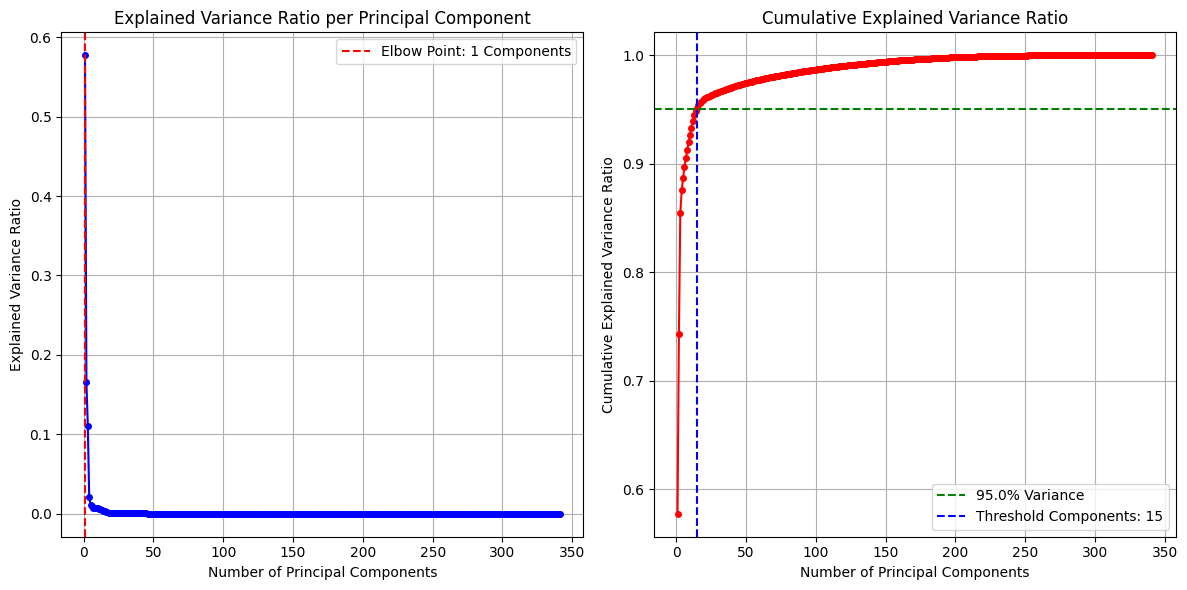

方差拐点对应的主成分数量: 1
达到95.0%方差解释率需要的主成分数量: 15
前15个主成分解释了总方差的95.15%

特征维度: 15 (PCA降维后)

类别分布:
标签 0: 训练集 124615, 测试集 41538, 验证集 41539, 总计 207692
标签 1: 训练集 9685, 测试集 3228, 验证集 3230, 总计 16143
标签 2: 训练集 9889, 测试集 3296, 验证集 3298, 总计 16483
标签 3: 训练集 111727, 测试集 37242, 验证集 37244, 总计 186213
标签 4: 训练集 102353, 测试集 34117, 验证集 34119, 总计 170589
标签 5: 训练集 41286, 测试集 13762, 验证集 13762, 总计 68810
标签 6: 训练集 69541, 测试集 23180, 验证集 23182, 总计 115903
标签 7: 训练集 27253, 测试集 9084, 验证集 9086, 总计 45423
标签 8: 训练集 10672, 测试集 3557, 验证集 3559, 总计 17788
标签 9: 训练集 2941, 测试集 980, 验证集 981, 总计 4902
标签 10: 训练集 57074, 测试集 19024, 验证集 19026, 总计 95124
标签 11: 训练集 55357, 测试集 18452, 验证集 18454, 总计 92263
标签 12: 训练集 22326, 测试集 7442, 验证集 7442, 总计 37210
标签 13: 训练集 17004, 测试集 5668, 验证集 5669, 总计 28341
标签 14: 训练集 8418, 测试集 2806, 验证集 2806, 总计 14030
标签 15: 训练集 5664, 测试集 1888, 验证集 1889, 总计 9441
标签 16: 训练集 59247, 测试集 19749, 验证集 19750, 总计 98746
标签 17: 训练集 3401, 测试集 1133, 验证集 1135, 总计 5669
标签 18: 训练集 10752, 测试集 3584, 验证集 3584, 总计 17920
标签 19: 训练集 16868,

训练进度::   0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/6371 [00:00<?, ?it/s]

轮次 0/100 损失:0.0035  准确率:3224.8892


  0%|          | 0/2124 [00:00<?, ?it/s]

...

轮次 99/100 损失:0.0026  准确率:4321.0269


  0%|          | 0/2124 [00:00<?, ?it/s]

轮次 99/100  验证准确率:0.3617  宏平均F1:0.3562  Kappa:0.3531  平衡准确率:0.4977
训练停止于轮次 99
训练时间: 10121.20秒
最佳模型 (f1_macro=0.3641): epoch_67_acc_0.3688_f1_0.3641.pth
在测试集上评估最佳模型...


评估中:   0%|          | 0/2124 [00:00<?, ?it/s]

ValueError: Number of classes, 100, does not match size of target_names, 102. Try specifying the labels parameter

In [16]:
# 定义数据目录路径
DATA_DIRS = {
    'train_dir': "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/train",
    'test_dir': "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/test",
    'val_dir': "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/val"
}

# # 如果是第一次运行，执行数据集重组
# # 注意：只需执行一次，后续运行应注释掉这段代码
# DATA_DIRS = setup_brain_voxel_data_structure()

# 载入多分类数据集
dataset_dict = load_multiclass_data(
    DATA_DIRS, 
    apply_pca_flag=APPLY_PCA, 
    n_components=N_PCA, 
    norm=NORM
)

# 保存PCA模型的引用
pca_model = dataset_dict.get('pca_model')

# 创建训练、测试和验证数据集
train_dataset = BrainVoxelDataset(dataset_dict['train_samples'], dataset_dict['train_labels'])
test_dataset = BrainVoxelDataset(dataset_dict['test_samples'], dataset_dict['test_labels'])
val_dataset = BrainVoxelDataset(dataset_dict['val_samples'], dataset_dict['val_labels'])

# 创建数据加载器
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 设置计算设备
device = torch.device(f"cuda:{DEVICE}" if DEVICE>=0 and torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 创建模型
feature_dim = dataset_dict['feature_dim']
model = BrainVoxelKAN(feature_dim, 64, NUM_CLASS, FIXED_GRID).to(device)

# 打印模型结构
summary(model)

# 计算类别权重并定义损失函数
class_weights = calculate_class_weights(dataset_dict['train_labels'])
class_weights = class_weights.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-1)  # 忽略背景像素

# 定义优化器
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# 训练模型
training_results = train_brain_voxel_kan_multiclass(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader, 
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=EPOCH,
    val_epoch=VAL_EPOCH,
    save_path=SAVE_PATH
)

# 获取最佳模型
best_model_path = get_best_model(
    training_results['val_f1_macro_list'],  # 使用宏平均F1作为选择标准
    training_results['val_epoch_list'],
    SAVE_PATH,
    metric='f1_macro'  # 指定使用F1宏平均作为指标
)

# 加载最佳模型
best_model = BrainVoxelKAN(feature_dim, 64, NUM_CLASS, FIXED_GRID).to(device)
best_model.load_state_dict(torch.load(best_model_path, weights_only=False)['state_dict'])

# 在测试集上评估
print("在测试集上评估最佳模型...")
test_results = evaluate_model_multiclass(best_model, test_loader, device)

# 打印主要评估指标
print(f"测试集准确率: {test_results['accuracy']:.4f}")
print(f"测试集平衡准确率: {test_results['balanced_accuracy']:.4f}")
print(f"测试集宏平均F1: {test_results['f1_macro']:.4f}")
print(f"测试集加权F1: {test_results['f1_weighted']:.4f}")
print(f"测试集Kappa系数: {test_results['kappa']:.4f}")

# 打印分类报告
print("\n分类报告:")
print(test_results['report'])

# 保存训练过程图表
plt.figure(figsize=(15, 5))

# 绘制损失曲线
plt.subplot(1, 3, 1)
plt.plot(range(len(training_results['loss_list'])), training_results['loss_list'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# 绘制准确率曲线
plt.subplot(1, 3, 2)
plt.plot(range(len(training_results['acc_list'])), training_results['acc_list'], label='Train Acc')
plt.plot(training_results['val_epoch_list'], training_results['val_acc_list'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 绘制F1和Kappa曲线
plt.subplot(1, 3, 3)
plt.plot(training_results['val_epoch_list'], training_results['val_f1_macro_list'], 'g-', label='F1 Macro')
plt.plot(training_results['val_epoch_list'], training_results['val_kappa_list'], 'r--', label='Kappa')
plt.title('F1 Macro & Kappa')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'training_curves_multiclass.png'))
plt.show()

# 可视化混淆矩阵 (对于多分类)
plt.figure(figsize=(12, 10))
conf_matrix = test_results['confusion_matrix']
# 使用对数缩放更好地显示不平衡的混淆矩阵
conf_matrix_vis = np.log1p(conf_matrix)  # log(1+x)以处理零值
mask = conf_matrix == 0
sns.heatmap(conf_matrix_vis, annot=False, fmt='d', cmap='Blues', 
          xticklabels=range(NUM_CLASS), yticklabels=range(NUM_CLASS),
          mask=mask)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (log scale)')
plt.savefig(os.path.join(SAVE_PATH, 'confusion_matrix_multiclass.png'))
plt.show()

# 保存测试结果
test_report = f"""
# 多分类测试报告

## 训练信息
- 训练时间: {training_results['train_time']:.2f} 秒
- 总训练轮数: {len(training_results['loss_list'])}
- 最佳模型: {os.path.basename(best_model_path)}
- 学习率: {LR}
- 批量大小: {BATCH_SIZE}
- 固定网格大小: {FIXED_GRID}

## 性能指标
- 测试集准确率: {test_results['accuracy']:.4f}
- 测试集平衡准确率: {test_results['balanced_accuracy']:.4f}
- 测试集宏平均F1: {test_results['f1_macro']:.4f}
- 测试集加权F1: {test_results['f1_weighted']:.4f}
- 测试集Kappa系数: {test_results['kappa']:.4f}

## 分类报告
{test_results['report']}
"""

with open(os.path.join(SAVE_PATH, 'test_report_multiclass.txt'), 'w') as f:
    f.write(test_report)

print(f"测试报告已保存至: {os.path.join(SAVE_PATH, 'test_report_multiclass.txt')}")

# 分析类别性能
class_f1 = test_results['class_f1']
class_precision = test_results['class_precision']
class_recall = test_results['class_recall']

# 找出表现最好和最差的类别
best_class = np.argmax(class_f1)
worst_class = np.argmin(class_f1)

print(f"表现最好的类别: {best_class}, F1分数: {class_f1[best_class]:.4f}")
print(f"表现最差的类别: {worst_class}, F1分数: {class_f1[worst_class]:.4f}")

# 绘制每个类别的F1分数分布
plt.figure(figsize=(15, 8))
plt.bar(range(len(class_f1)), class_f1)
plt.xlabel('Class Index')
plt.ylabel('F1 Score')
plt.title('F1 Score by Class')
plt.grid(True)
plt.savefig(os.path.join(SAVE_PATH, 'class_f1_distribution.png'))
plt.show()

In [17]:
def analyze_kan_model(model, data_samples, save_path=None, apply_pca_flag=True, pca_model=None):
    """
    简单分析KAN模型的特征重要性
    
    参数:
        model: 训练好的KAN模型
        data_samples: 数据样本
        save_path: 保存路径，None表示不保存
        apply_pca_flag: 是否应用了PCA
        pca_model: PCA模型，用于反向解释特征重要性
    """
    # 获取模型输入层的权重
    input_weights = model.kan.layers[0].base_linear.weight.data.cpu().numpy()
    
    # 计算特征的平均绝对权重值（简单的重要性度量）
    feature_importance = np.mean(np.abs(input_weights), axis=0)
    
    # 找出前20个最重要的特征
    top_n = min(20, len(feature_importance))
    top_indices = np.argsort(feature_importance)[-top_n:][::-1]
    top_importance = feature_importance[top_indices]
    
    # 可视化特征重要性
    plt.figure(figsize=(12, 8))
    
    if apply_pca_flag:
        feature_names = [f"PC {i+1}" for i in top_indices]
        title = f"Top {top_n} Principal Component Importance"
        
        # 如果有PCA模型，可以尝试显示每个PC的原始特征贡献
        if pca_model is not None:
            plt.figure(figsize=(15, 10))
            # 创建一个额外的图显示PC的组成
            for i, pc_idx in enumerate(top_indices[:5]): # 只显示前5个最重要的PC
                if i < 5: # 限制显示数量
                    plt.subplot(5, 1, i+1)
                    pc_components = pca_model.components_[pc_idx]
                    plt.bar(range(len(pc_components)), pc_components)
                    plt.title(f"PC {pc_idx+1} Component Composition")
                    plt.xlabel('Original Feature Index')
                    plt.ylabel('Weight')
            plt.tight_layout()
            if save_path:
                base_path, ext = os.path.splitext(save_path)
                pc_comp_path = f"{base_path}_pc_composition{ext}"
                plt.savefig(pc_comp_path)
                print(f"保存PC组成图到：{pc_comp_path}")
            plt.figure(figsize=(12, 8)) # 恢复原始图形
    else:
        feature_names = [f"Feature {i+1}" for i in top_indices]
        title = f"Top {top_n} Feature Importance"
    
    plt.barh(range(top_n), top_importance, align='center')
    plt.yticks(range(top_n), feature_names)
    plt.xlabel('Mean Absolute Weight')
    plt.title(title)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    
    plt.show()
    
    # 保存特征重要性数据
    importance_data = {
        'feature_index': np.arange(len(feature_importance)),
        'importance': feature_importance,
        'is_pca': apply_pca_flag,
        'pca_model': pca_model if apply_pca_flag else None
    }
    
    return importance_data



在训练集上进行全面评估...


训练集评估:   0%|          | 0/6371 [00:00<?, ?it/s]

训练集准确率: 0.3646
训练集平衡准确率: 0.5111
训练集宏平均F1: 0.3629
训练集加权F1: 0.3657
训练集Kappa系数: 0.3560

分类报告:
              precision    recall  f1-score   support

           0       0.32      0.79      0.45      9685
           1       0.22      0.87      0.35      9889
           2       0.80      0.54      0.65    111727
           3       0.71      0.61      0.66    102353
           4       0.52      0.56      0.54     41286
           5       0.67      0.57      0.62     69541
           6       0.57      0.74      0.64     27253
           7       0.70      0.76      0.73     10672
           8       0.21      0.98      0.35      2941
           9       0.75      0.68      0.71     57074
          10       0.40      0.30      0.34     55357
          11       0.37      0.49      0.42     22326
          12       0.41      0.66      0.51     17004
          13       0.19      0.83      0.31      8418
          14       0.26      0.81      0.40      5664
          15       0.55      0.32      0.40 

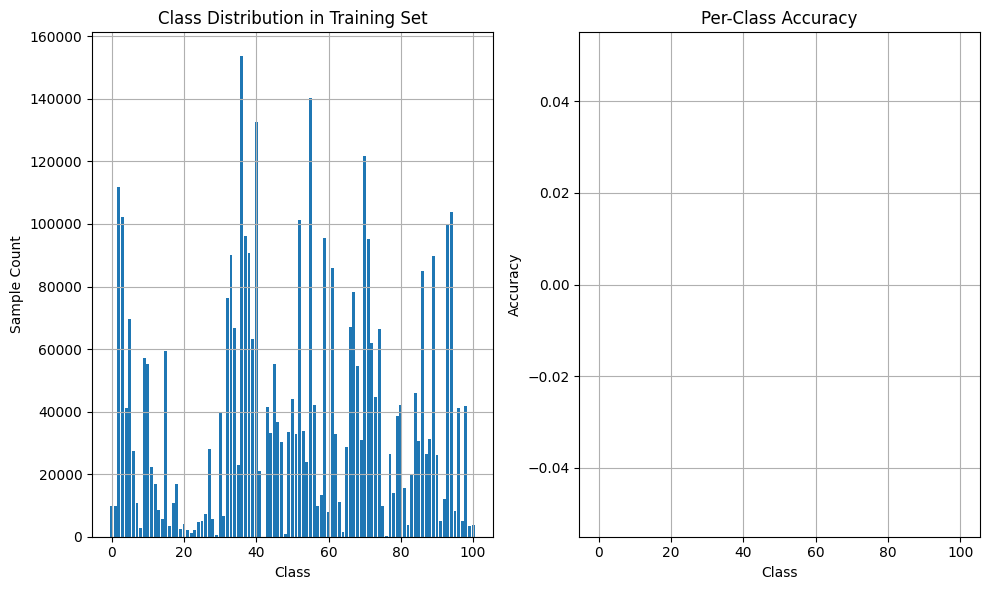

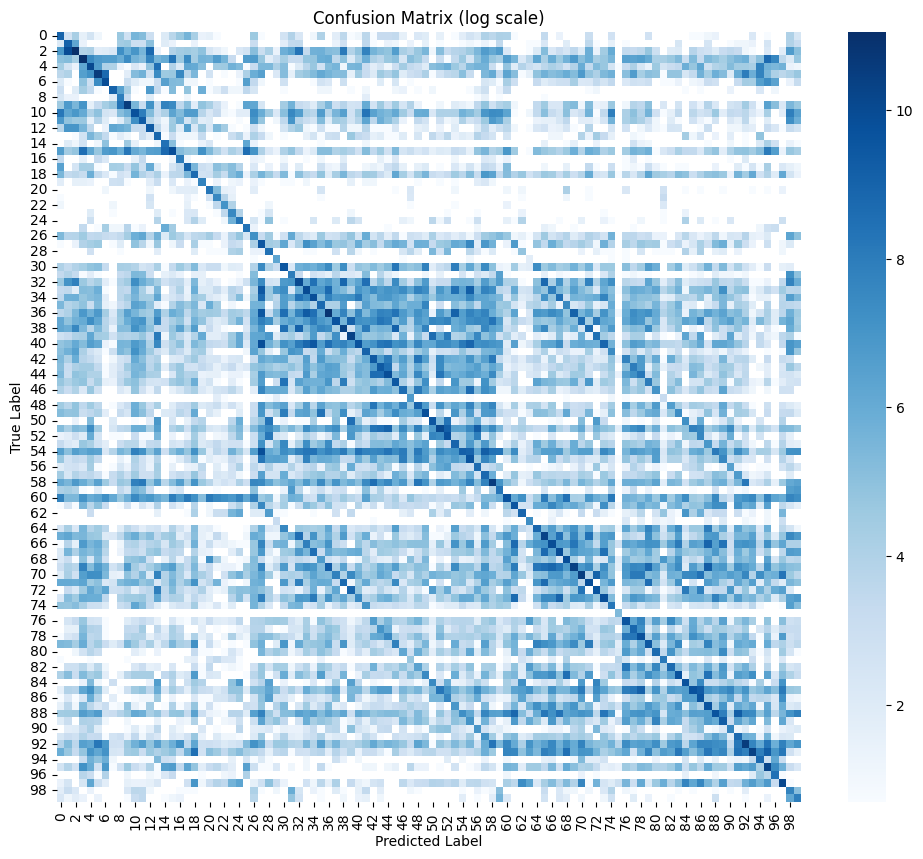

IndexError: index 100 is out of bounds for axis 0 with size 100

<Figure size 1500x600 with 0 Axes>

In [18]:
# 在训练集上进行全面评估
print("在训练集上进行全面评估...")
model.eval()
train_preds = []
train_targets = []
train_probs_all = []  # 所有类别的概率

# 使用train_loader直接评估
with torch.no_grad():
    for data, target in tqdm(train_loader, desc="训练集评估"):
        data, target = data.to(device), target.to(device)
        output = model(data)
        probs = torch.softmax(output, dim=1)
        _, preds = torch.max(output, 1)
        
        # 只评估非背景像素
        valid_mask = target != -1
        train_preds.extend(preds[valid_mask].cpu().numpy())
        train_targets.extend(target[valid_mask].cpu().numpy())
        train_probs_all.extend(probs[valid_mask].cpu().numpy())  # 保存所有类别的概率

# 计算各种评估指标
train_accuracy = accuracy_score(train_targets, train_preds)
train_balanced_acc = balanced_accuracy_score(train_targets, train_preds)
train_f1_macro = f1_score(train_targets, train_preds, average='macro')
train_f1_weighted = f1_score(train_targets, train_preds, average='weighted')
train_kappa = cohen_kappa_score(train_targets, train_preds)

train_report = classification_report(train_targets, train_preds)
train_conf_matrix = confusion_matrix(train_targets, train_preds)

# 打印主要评估指标
print(f"训练集准确率: {train_accuracy:.4f}")
print(f"训练集平衡准确率: {train_balanced_acc:.4f}")
print(f"训练集宏平均F1: {train_f1_macro:.4f}")
print(f"训练集加权F1: {train_f1_weighted:.4f}")
print(f"训练集Kappa系数: {train_kappa:.4f}")

print("\n分类报告:")
print(train_report)
print("\n混淆矩阵:")
print(train_conf_matrix)

# 可视化类别分布
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
# 统计每个类别的样本数
class_counts = np.bincount(train_targets)
classes = np.arange(len(class_counts))
plt.bar(classes, class_counts)
plt.xlabel('Class')
plt.ylabel('Sample Count')
plt.title('Class Distribution in Training Set')
plt.grid(True)

# 统计每个类别的预测准确率
plt.subplot(1, 2, 2)
class_accuracy = []
for cls in range(len(class_counts)):
    if cls in np.unique(train_targets):
        mask = train_targets == cls
        if np.sum(mask) > 0:
            acc = np.mean(np.array(train_preds)[mask] == cls)
            class_accuracy.append(acc)
        else:
            class_accuracy.append(0)
    else:
        class_accuracy.append(0)

plt.bar(np.arange(len(class_accuracy)), class_accuracy)
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'training_set_class_distribution.png'))
plt.show()

# 创建多分类混淆矩阵可视化
plt.figure(figsize=(12, 10))
# 使用对数缩放更好地显示不平衡的混淆矩阵
conf_mat_log = np.log1p(train_conf_matrix)  # log(1+x)以处理零值
mask = train_conf_matrix == 0
sns.heatmap(conf_mat_log, annot=False, fmt='d', cmap='Blues',
            mask=mask)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (log scale)')
plt.savefig(os.path.join(SAVE_PATH, 'training_confusion_matrix_multiclass.png'))
plt.show()

# 计算每个类别的精确率、召回率和F1分数
class_precision = precision_score(train_targets, train_preds, average=None, zero_division=0)
class_recall = recall_score(train_targets, train_preds, average=None, zero_division=0)
class_f1 = f1_score(train_targets, train_preds, average=None, zero_division=0)

# 可视化类别性能
plt.figure(figsize=(15, 6))
# 只选择有实际样本的类别
valid_classes = np.where(class_counts > 0)[0]
x = np.arange(len(valid_classes))
width = 0.25

plt.bar(x - width, class_precision[valid_classes], width, label='Precision')
plt.bar(x, class_recall[valid_classes], width, label='Recall')
plt.bar(x + width, class_f1[valid_classes], width, label='F1')

plt.xlabel('Class')
plt.ylabel('Score')
plt.title('Per-Class Performance Metrics')
plt.xticks(x, valid_classes)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'training_set_class_performance.png'))
plt.show()

# 保存训练集评估报告
train_report_complete = f"""
# 训练集多分类全面评估报告

## 性能指标
- 准确率: {train_accuracy:.4f}
- 平衡准确率: {train_balanced_acc:.4f}
- 宏平均F1: {train_f1_macro:.4f}
- 加权F1: {train_f1_weighted:.4f}
- Kappa系数: {train_kappa:.4f}

## 样本分布
- 总样本数: {len(train_targets)}
- 类别数量: {len(np.unique(train_targets))}
- 样本最多的类别: {np.argmax(class_counts)} ({np.max(class_counts)} 个样本)
- 样本最少的类别: {np.argmin(class_counts[class_counts > 0])} ({np.min(class_counts[class_counts > 0])} 个样本)

## 类别性能分析
"""

# 添加类别性能表格
train_report_complete += """
| 类别 | 样本数 | 精确率 | 召回率 | F1分数 |
|------|--------|--------|--------|--------|
"""

for cls in valid_classes:
    train_report_complete += f"| {cls} | {class_counts[cls]} | {class_precision[cls]:.4f} | {class_recall[cls]:.4f} | {class_f1[cls]:.4f} |\n"

train_report_complete += f"""
## 分类报告
{train_report}

## 性能分析
- 表现最好的类别: {valid_classes[np.argmax(class_f1[valid_classes])]} (F1分数: {np.max(class_f1[valid_classes]):.4f})
- 表现最差的类别: {valid_classes[np.argmin(class_f1[valid_classes])]} (F1分数: {np.min(class_f1[valid_classes]):.4f})
- 类别间性能差异: {np.max(class_f1[valid_classes]) - np.min(class_f1[valid_classes]):.4f}
"""

with open(os.path.join(SAVE_PATH, 'training_set_complete_report_multiclass.txt'), 'w') as f:
    f.write(train_report_complete)

print(f"训练集全面评估报告已保存至: {os.path.join(SAVE_PATH, 'training_set_complete_report_multiclass.txt')}")

In [19]:
# 在测试集上进行全面评估
print("在测试集上进行多分类全面评估...")
model.eval()
test_preds = []
test_probs = []
test_targets = []

# 使用test_loader直接评估
with torch.no_grad():
    for data, target in tqdm(test_loader, desc="测试集评估"):
        data, target = data.to(device), target.to(device)
        output = model(data)
        probs = torch.softmax(output, dim=1)
        _, preds = torch.max(output, 1)
        
        # 只收集有效标签（忽略-1）
        valid_mask = target != -1
        test_preds.extend(preds[valid_mask].cpu().numpy())
        test_probs.extend(probs[valid_mask].cpu().numpy())  # 保存所有类别的概率
        test_targets.extend(target[valid_mask].cpu().numpy())

# 计算多分类评估指标
test_accuracy = accuracy_score(test_targets, test_preds)
test_balanced_acc = balanced_accuracy_score(test_targets, test_preds)
test_f1_macro = f1_score(test_targets, test_preds, average='macro')
test_f1_weighted = f1_score(test_targets, test_preds, average='weighted')
test_kappa = cohen_kappa_score(test_targets, test_preds)

# 为每个类别计算指标
test_class_precision = precision_score(test_targets, test_preds, average=None, zero_division=0)
test_class_recall = recall_score(test_targets, test_preds, average=None, zero_division=0)
test_class_f1 = f1_score(test_targets, test_preds, average=None, zero_division=0)

# 生成分类报告 - 标签名称使用Class 0, Class 1等
class_names = [f"Class {i}" for i in range(NUM_CLASS)]
test_report = classification_report(test_targets, test_preds, target_names=class_names, zero_division=0)
test_conf_matrix = confusion_matrix(test_targets, test_preds)

# 打印主要评估指标
print(f"测试集准确率: {test_accuracy:.4f}")
print(f"测试集平衡准确率: {test_balanced_acc:.4f}")
print(f"测试集宏平均F1: {test_f1_macro:.4f}")
print(f"测试集加权F1: {test_f1_weighted:.4f}")
print(f"测试集Kappa系数: {test_kappa:.4f}")
print(f"测试集样本总数: {len(test_targets)}")

# 统计各类别的样本数
print("\n类别分布:")
unique_classes, class_counts = np.unique(test_targets, return_counts=True)
for cls, count in zip(unique_classes, class_counts):
    print(f"类别 {cls}: {count} 个样本")

print("\n分类报告:")
print(test_report)

# 创建更适合多分类的可视化
plt.figure(figsize=(15, 12))

# 1. 准确率和F1分数
plt.subplot(2, 2, 1)
metrics = ['Accuracy', 'Balanced Acc', 'Macro F1', 'Weighted F1', 'Kappa']
values = [test_accuracy, test_balanced_acc, test_f1_macro, test_f1_weighted, test_kappa]
plt.bar(metrics, values, color='steelblue')
plt.ylabel('Score')
plt.title('Test Set Performance Metrics')
plt.ylim(0, 1)
plt.grid(axis='y')
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center')

# 2. 类别F1分数分布 - 只显示前20个类别，避免过于拥挤
plt.subplot(2, 2, 2)
top_k = 20  # 显示前20个类别
sorted_idx = np.argsort(test_class_f1)[-top_k:]  # 获取F1分数最高的top_k个类别
plt.barh([f"Class {i}" for i in sorted_idx], test_class_f1[sorted_idx], color='lightgreen')
plt.xlabel('F1 Score')
plt.title(f'Top {top_k} Classes by F1 Score')
plt.grid(axis='x')

# 3. 混淆矩阵热图 - 采用对数变换来更好地可视化
plt.subplot(2, 2, 3)
conf_matrix_log = np.log1p(test_conf_matrix)  # log(1+x) 处理
sns.heatmap(conf_matrix_log, cmap='Blues', fmt='', xticklabels=20, yticklabels=20)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix (log scale)')

# 4. 类别样本数量与F1分数关系
plt.subplot(2, 2, 4)
class_indices = np.arange(len(test_class_f1))
plt.scatter(np.bincount(test_targets, minlength=NUM_CLASS)[class_indices], 
            test_class_f1, alpha=0.7)
plt.xlabel('Sample Count')
plt.ylabel('F1 Score')
plt.title('Class Sample Count vs. F1 Score')
plt.grid(True)
plt.xscale('log')  # 对样本数使用对数刻度，更好地可视化

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'test_set_multiclass_performance.png'))
plt.show()

# 保存测试集评估报告
test_report_complete = f"""
# 测试集多分类评估报告 (102类)

## 整体性能指标
- 准确率: {test_accuracy:.4f}
- 平衡准确率: {test_balanced_acc:.4f}
- 宏平均F1分数: {test_f1_macro:.4f}
- 加权F1分数: {test_f1_weighted:.4f}
- Kappa系数: {test_kappa:.4f}

## 样本分布
- 总样本数: {len(test_targets)}
- 类别数: {len(unique_classes)}
- 最大类样本数: {max(class_counts)}
- 最小类样本数: {min(class_counts)}
- 类别不平衡比例: {max(class_counts)/min(class_counts):.2f}

## 表现最好的10个类别 (按F1分数)
"""

# 添加表现最好的10个类别
best_classes = np.argsort(test_class_f1)[-10:][::-1]
test_report_complete += """
| 类别ID | 精确率 | 召回率 | F1分数 | 样本数 |
|--------|--------|--------|--------|--------|
"""
for class_id in best_classes:
    if class_id < len(test_class_precision):  # 确保索引有效
        precision = test_class_precision[class_id]
        recall = test_class_recall[class_id]
        f1 = test_class_f1[class_id]
        sample_count = np.sum(test_targets == class_id)
        test_report_complete += f"| {class_id} | {precision:.4f} | {recall:.4f} | {f1:.4f} | {sample_count} |\n"

test_report_complete += """
## 表现最差的10个类别 (按F1分数)
"""

# 添加表现最差的10个类别
worst_classes = np.argsort(test_class_f1)[:10]
test_report_complete += """
| 类别ID | 精确率 | 召回率 | F1分数 | 样本数 |
|--------|--------|--------|--------|--------|
"""
for class_id in worst_classes:
    if class_id < len(test_class_precision):  # 确保索引有效
        precision = test_class_precision[class_id]
        recall = test_class_recall[class_id]
        f1 = test_class_f1[class_id]
        sample_count = np.sum(test_targets == class_id)
        test_report_complete += f"| {class_id} | {precision:.4f} | {recall:.4f} | {f1:.4f} | {sample_count} |\n"

# 分析样本数量与性能的关系
sample_counts = np.bincount(test_targets, minlength=NUM_CLASS)
correlation = np.corrcoef(sample_counts, test_class_f1)[0, 1]
test_report_complete += f"""
## 样本数量对性能的影响
- 样本数量与F1分数的相关系数: {correlation:.4f}
- 最多样本的类别: 类别 {np.argmax(sample_counts)}, {max(sample_counts)} 个样本, F1分数: {test_class_f1[np.argmax(sample_counts)]:.4f}
- 最少样本的类别: 类别 {np.argmin(sample_counts[sample_counts > 0])}, {min(sample_counts[sample_counts > 0])} 个样本, F1分数: {test_class_f1[np.argmin(sample_counts[sample_counts > 0])]:.4f}

## 小样本类别分析
"""

# 分析小样本类别
small_sample_threshold = 10
small_sample_classes = [i for i, count in enumerate(sample_counts) if 0 < count < small_sample_threshold]
test_report_complete += f"- 样本数少于{small_sample_threshold}的类别: {len(small_sample_classes)}个\n"
if small_sample_classes:
    small_sample_f1 = [test_class_f1[i] for i in small_sample_classes]
    test_report_complete += f"- 小样本类别的平均F1分数: {np.mean(small_sample_f1):.4f}\n"
    test_report_complete += f"- 其他类别的平均F1分数: {np.mean([test_class_f1[i] for i in range(NUM_CLASS) if i not in small_sample_classes and i < len(test_class_f1)]):.4f}\n"

test_report_complete += """
## 完整分类报告
"""
test_report_complete += test_report

with open(os.path.join(SAVE_PATH, 'test_set_multiclass_report.txt'), 'w') as f:
    f.write(test_report_complete)

print(f"测试集多分类评估报告已保存至: {os.path.join(SAVE_PATH, 'test_set_multiclass_report.txt')}")

在测试集上进行多分类全面评估...


测试集评估:   0%|          | 0/2124 [00:00<?, ?it/s]

ValueError: Number of classes, 100, does not match size of target_names, 102. Try specifying the labels parameter

在验证集上进行全面评估...


验证集评估:   0%|          | 0/2124 [00:00<?, ?it/s]

验证集准确率: 0.3617
验证集平衡准确率: 0.4977
验证集宏平均F1: 0.3562
验证集加权F1: 0.3635
验证集Kappa系数: 0.3531

分类报告:
              precision    recall  f1-score   support

           0       0.31      0.78      0.44      3230
           1       0.22      0.87      0.35      3298
           2       0.80      0.54      0.64     37244
           3       0.71      0.62      0.66     34119
           4       0.51      0.55      0.53     13762
           5       0.67      0.56      0.61     23182
           6       0.56      0.73      0.63      9086
           7       0.69      0.75      0.72      3559
           8       0.21      0.97      0.35       981
           9       0.76      0.68      0.71     19026
          10       0.40      0.30      0.34     18454
          11       0.36      0.48      0.42      7442
          12       0.40      0.65      0.50      5669
          13       0.18      0.81      0.30      2806
          14       0.26      0.79      0.39      1889
          15       0.54      0.31      0.39 

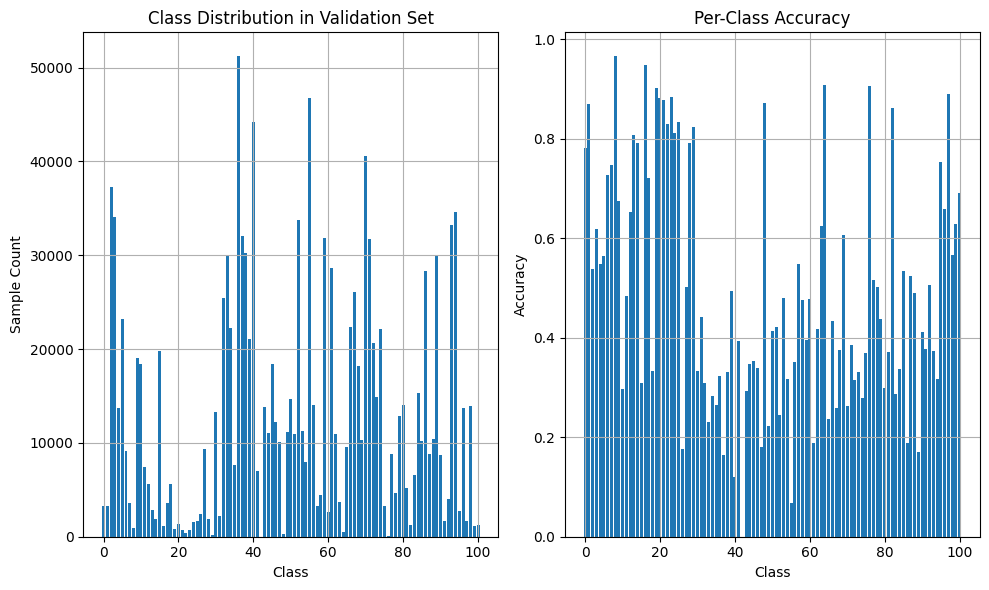

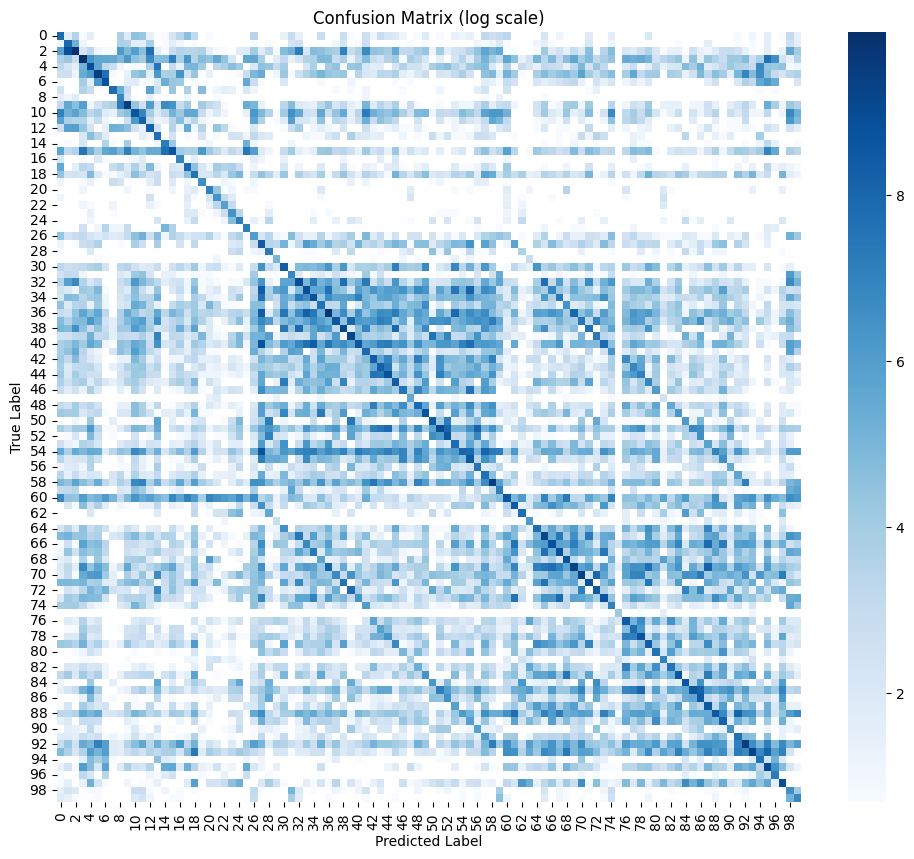

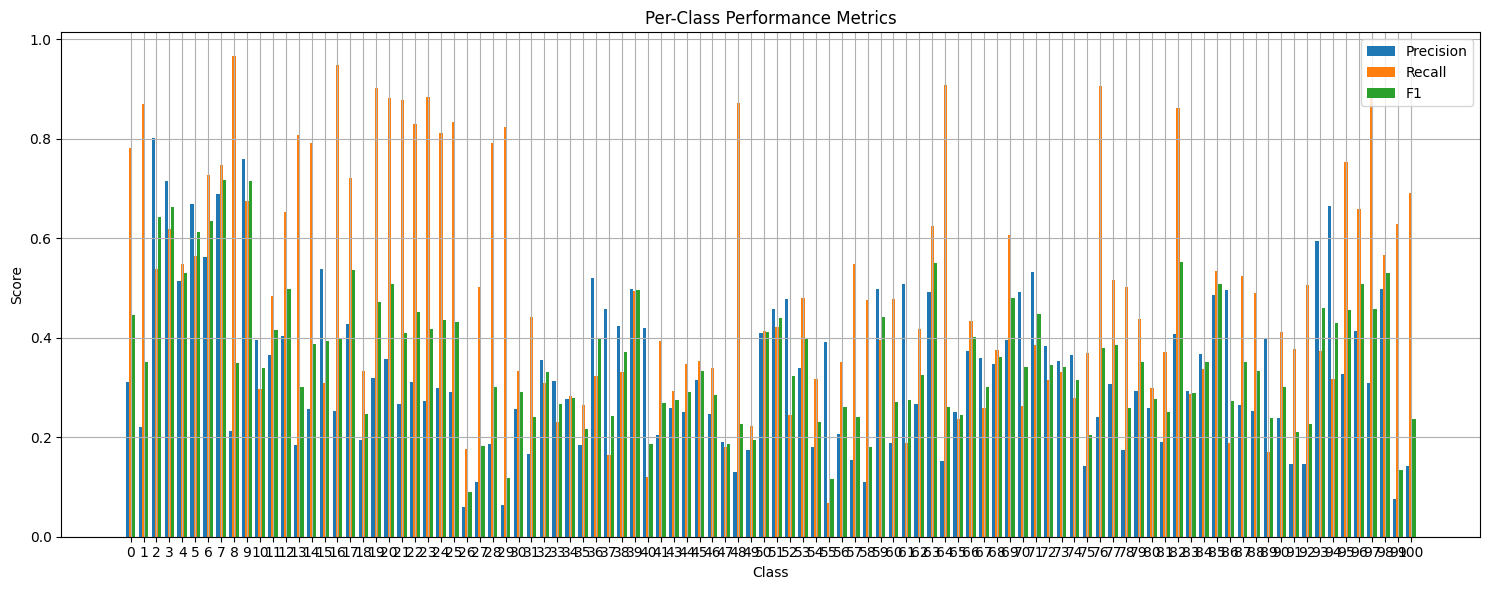

验证集全面评估报告已保存至: ./Results/BrainVoxel_102Class/BrainVoxel/validation_complete_report_multiclass.txt


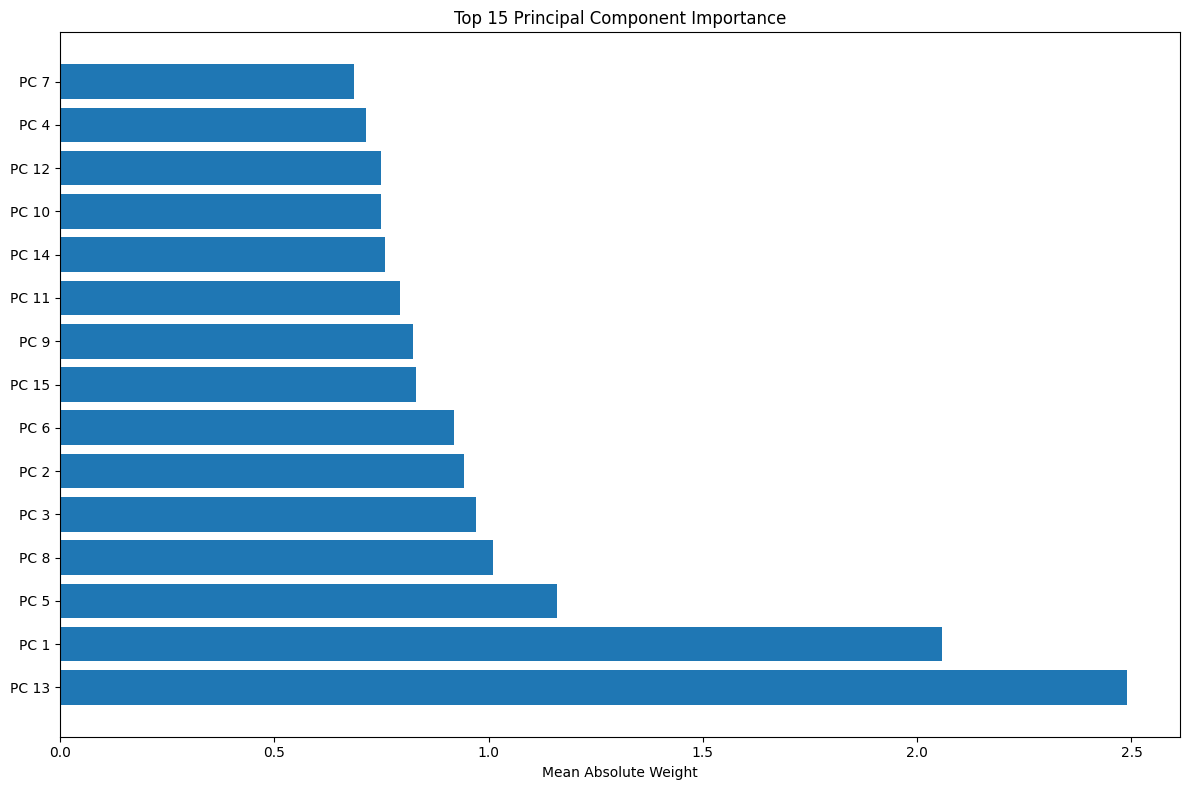

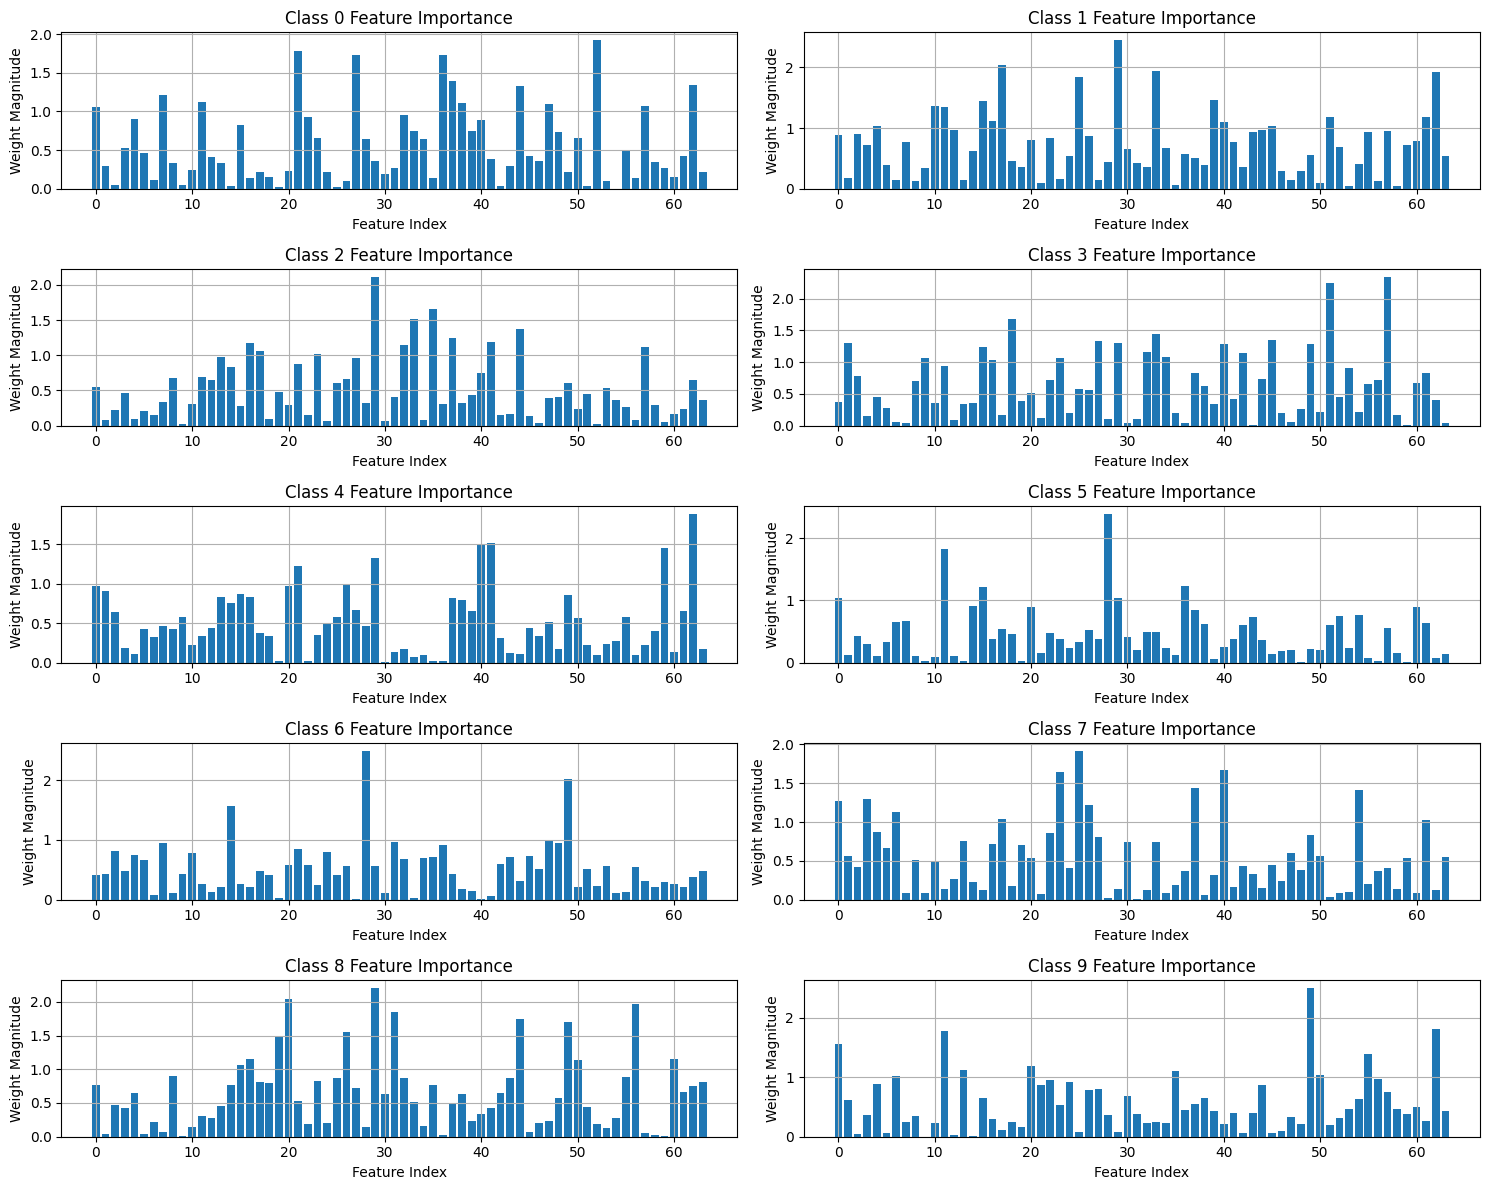

每个类别的特征重要性分析已完成并保存


In [20]:
# 在验证集上进行全面评估
print("在验证集上进行全面评估...")
model.eval()
all_preds = []
all_probs_all = []  # 存储所有类别的概率
all_targets = []

# 使用val_loader直接评估
with torch.no_grad():
    for data, target in tqdm(val_loader, desc="验证集评估"):
        data, target = data.to(device), target.to(device)
        output = model(data)
        probs = torch.softmax(output, dim=1)
        _, preds = torch.max(output, 1)
        
        # 只评估非背景像素
        valid_mask = target != -1
        all_preds.extend(preds[valid_mask].cpu().numpy())
        all_probs_all.extend(probs[valid_mask].cpu().numpy())
        all_targets.extend(target[valid_mask].cpu().numpy())

# 转换为numpy数组
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs_all = np.array(all_probs_all)

# 计算各种评估指标
accuracy = accuracy_score(all_targets, all_preds)
balanced_acc = balanced_accuracy_score(all_targets, all_preds)
f1_macro = f1_score(all_targets, all_preds, average='macro')
f1_weighted = f1_score(all_targets, all_preds, average='weighted')
kappa = cohen_kappa_score(all_targets, all_preds)

report = classification_report(all_targets, all_preds)
conf_matrix = confusion_matrix(all_targets, all_preds)

# 打印主要评估指标
print(f"验证集准确率: {accuracy:.4f}")
print(f"验证集平衡准确率: {balanced_acc:.4f}")
print(f"验证集宏平均F1: {f1_macro:.4f}")
print(f"验证集加权F1: {f1_weighted:.4f}")
print(f"验证集Kappa系数: {kappa:.4f}")

print("\n分类报告:")
print(report)
print("\n混淆矩阵:")
print(conf_matrix)

# 可视化类别分布
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
# 统计每个类别的样本数
class_counts = np.bincount(all_targets.astype(int))
classes = np.arange(len(class_counts))
plt.bar(classes, class_counts)
plt.xlabel('Class')
plt.ylabel('Sample Count')
plt.title('Class Distribution in Validation Set')
plt.grid(True)

# 统计每个类别的预测准确率
plt.subplot(1, 2, 2)
class_accuracy = []
for cls in range(len(class_counts)):
    if cls in np.unique(all_targets):
        mask = all_targets == cls
        if np.sum(mask) > 0:
            acc = np.mean(all_preds[mask] == cls)
            class_accuracy.append(acc)
        else:
            class_accuracy.append(0)
    else:
        class_accuracy.append(0)

plt.bar(np.arange(len(class_accuracy)), class_accuracy)
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'validation_set_class_distribution.png'))
plt.show()

# 创建多分类混淆矩阵可视化
plt.figure(figsize=(12, 10))
# 使用对数缩放更好地显示不平衡的混淆矩阵
conf_mat_log = np.log1p(conf_matrix)  # log(1+x)以处理零值
mask = conf_matrix == 0
sns.heatmap(conf_mat_log, annot=False, fmt='d', cmap='Blues',
            mask=mask)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (log scale)')
plt.savefig(os.path.join(SAVE_PATH, 'validation_confusion_matrix_multiclass.png'))
plt.show()

# 计算每个类别的精确率、召回率和F1分数
valid_classes = np.unique(all_targets).astype(int)
class_precision = precision_score(all_targets, all_preds, average=None, labels=valid_classes, zero_division=0)
class_recall = recall_score(all_targets, all_preds, average=None, labels=valid_classes, zero_division=0)
class_f1 = f1_score(all_targets, all_preds, average=None, labels=valid_classes, zero_division=0)

# 可视化类别性能
plt.figure(figsize=(15, 6))
x = np.arange(len(valid_classes))
width = 0.25

plt.bar(x - width, class_precision, width, label='Precision')
plt.bar(x, class_recall, width, label='Recall')
plt.bar(x + width, class_f1, width, label='F1')

plt.xlabel('Class')
plt.ylabel('Score')
plt.title('Per-Class Performance Metrics')
plt.xticks(x, valid_classes)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'validation_set_class_performance.png'))
plt.show()

# 保存验证集评估报告
validation_report_complete = f"""
# 验证集多分类全面评估报告

## 性能指标
- 准确率: {accuracy:.4f}
- 平衡准确率: {balanced_acc:.4f}
- 宏平均F1: {f1_macro:.4f}
- 加权F1: {f1_weighted:.4f}
- Kappa系数: {kappa:.4f}

## 样本分布
- 总样本数: {len(all_targets)}
- 类别数量: {len(valid_classes)}
"""

# 添加各类别的样本数
validation_report_complete += """
## 类别分布

| 类别 | 样本数 | 所占比例 |
|------|--------|----------|
"""

for cls in valid_classes:
    count = np.sum(all_targets == cls)
    percentage = count / len(all_targets) * 100
    validation_report_complete += f"| {cls} | {count} | {percentage:.2f}% |\n"

# 添加类别性能表格
validation_report_complete += """
## 类别性能分析

| 类别 | 精确率 | 召回率 | F1分数 |
|------|--------|--------|--------|
"""

for i, cls in enumerate(valid_classes):
    validation_report_complete += f"| {cls} | {class_precision[i]:.4f} | {class_recall[i]:.4f} | {class_f1[i]:.4f} |\n"

# 添加分类报告
validation_report_complete += f"""
## 详细分类报告
{report}

## 性能分析
- 表现最好的类别: {valid_classes[np.argmax(class_f1)]} (F1分数: {np.max(class_f1):.4f})
- 表现最差的类别: {valid_classes[np.argmin(class_f1)]} (F1分数: {np.min(class_f1):.4f})
- 类别间性能差异: {np.max(class_f1) - np.min(class_f1):.4f}
"""

with open(os.path.join(SAVE_PATH, 'validation_complete_report_multiclass.txt'), 'w') as f:
    f.write(validation_report_complete)

print(f"验证集全面评估报告已保存至: {os.path.join(SAVE_PATH, 'validation_complete_report_multiclass.txt')}")

# 特征重要性分析
feature_importance = analyze_kan_model(
    best_model,
    dataset_dict['val_samples'],
    os.path.join(SAVE_PATH, 'feature_importance_validation_multiclass.png'),
    apply_pca_flag=APPLY_PCA 
)

# 保存特征重要性数据
np.save(os.path.join(SAVE_PATH, 'feature_importance_validation_multiclass.npy'), feature_importance)

# 分析每个类别的特征重要性（如果可能）
if hasattr(model, 'kan') and hasattr(model.kan, 'layers'):
    try:
        # 尝试获取最后一层权重
        final_layer_weights = model.kan.layers[-1].base_linear.weight.data.cpu().numpy()
        
        # 可视化前10个类别的特征重要性
        plt.figure(figsize=(15, 12))
        num_classes_to_show = min(10, final_layer_weights.shape[0])
        
        for i in range(num_classes_to_show):
            plt.subplot(5, 2, i+1)
            class_weights = np.abs(final_layer_weights[i])
            plt.bar(range(len(class_weights)), class_weights)
            plt.title(f'Class {i} Feature Importance')
            plt.xlabel('Feature Index')
            plt.ylabel('Weight Magnitude')
            plt.grid(True)
        
        plt.tight_layout()
        plt.savefig(os.path.join(SAVE_PATH, 'class_specific_feature_importance.png'))
        plt.show()
        
        print("每个类别的特征重要性分析已完成并保存")
    except Exception as e:
        print(f"无法分析每个类别的特征重要性: {e}")

在merged全数据集上进行评估...
找到 101 个有效标签


加载merged数据集:   0%|          | 0/101 [00:00<?, ?it/s]

使用训练好的PCA模型转换merged数据...


merged数据集评估:   0%|          | 0/10618 [00:00<?, ?it/s]

merged数据集准确率: 0.3633
merged数据集平衡准确率: 0.5058
merged数据集宏平均F1: 0.3601
merged数据集加权F1: 0.3646
merged数据集Kappa系数: 0.3547

分类报告:
              precision    recall  f1-score   support

           0       0.31      0.79      0.45     16143
           1       0.22      0.87      0.35     16483
           2       0.80      0.54      0.65    186213
           3       0.71      0.62      0.66    170589
           4       0.52      0.55      0.54     68810
           5       0.67      0.57      0.62    115903
           6       0.57      0.73      0.64     45423
           7       0.70      0.76      0.73     17788
           8       0.21      0.97      0.35      4902
           9       0.75      0.67      0.71     95124
          10       0.39      0.30      0.34     92263
          11       0.37      0.49      0.42     37210
          12       0.41      0.66      0.50     28341
          13       0.19      0.82      0.30     14030
          14       0.26      0.80      0.39      9441
          15  

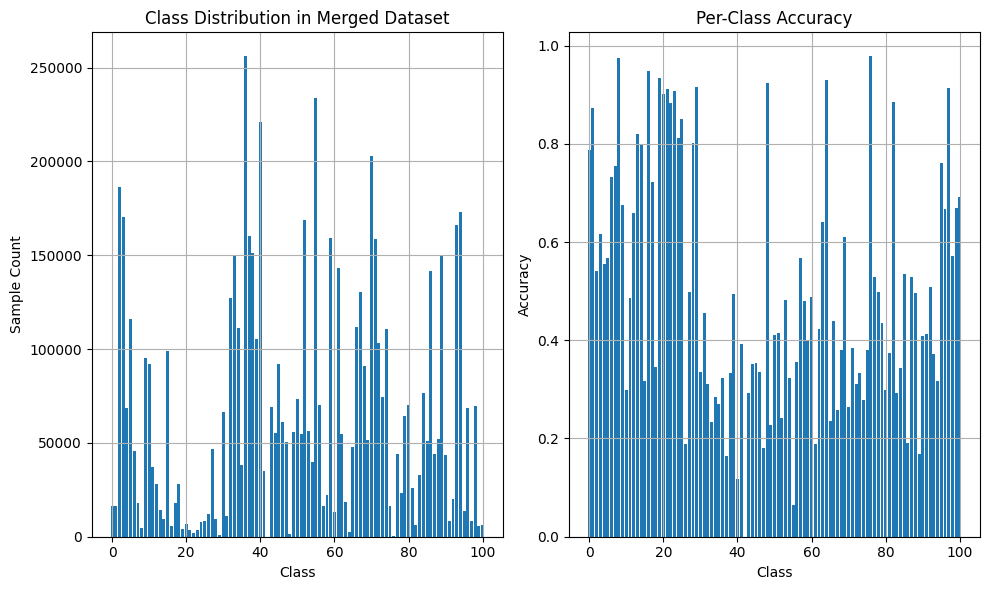

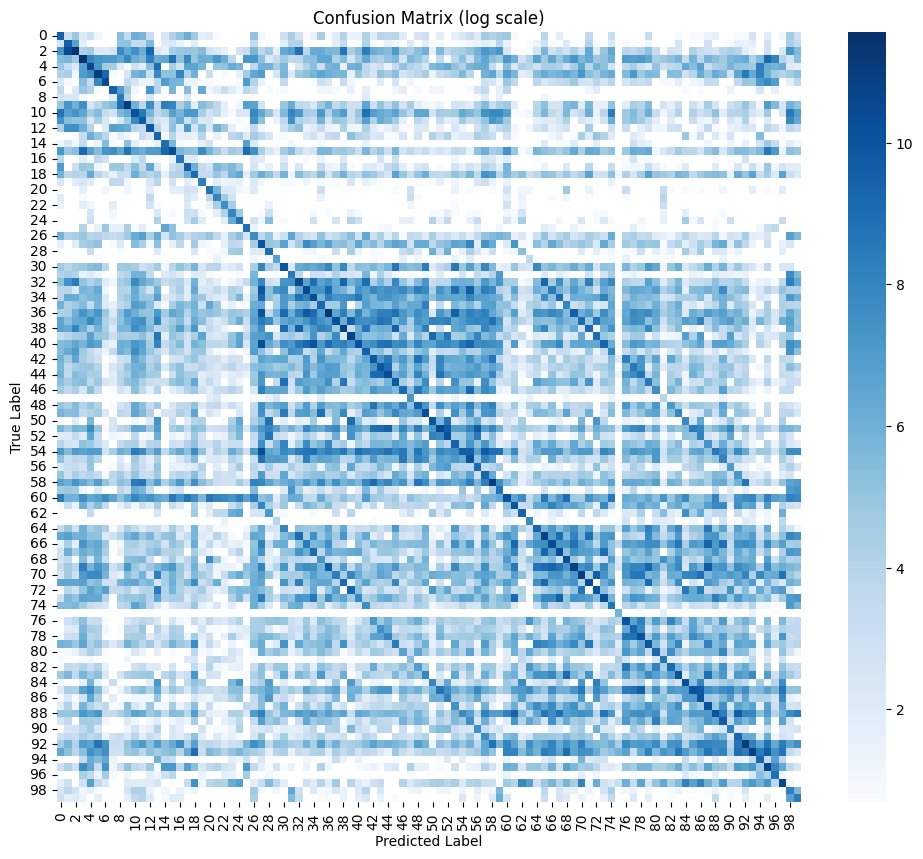

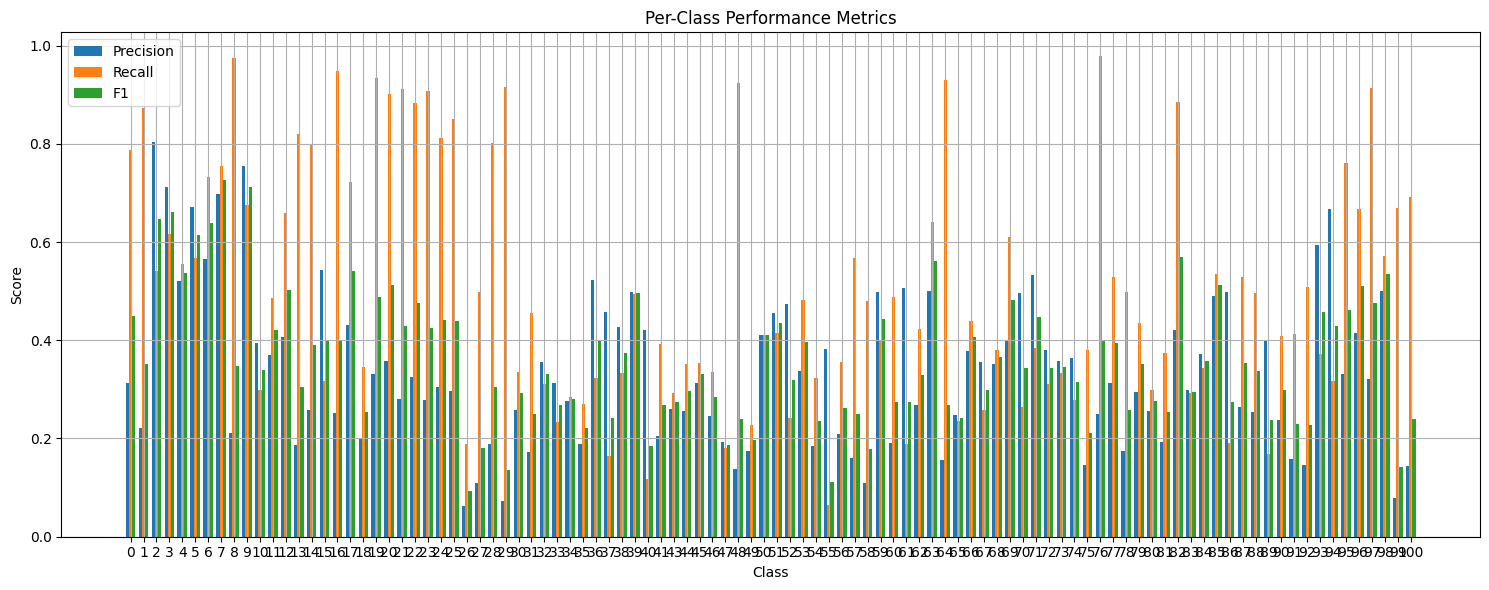

表现最好的类别: 7, F1分数: 0.7254
表现最差的类别: 26, F1分数: 0.0940
Merged数据集评估报告已保存至: ./Results/BrainVoxel_102Class/BrainVoxel/merged_dataset_complete_report_multiclass.txt


In [21]:
# 在merged全数据集上进行评估
print("在merged全数据集上进行评估...")

# 定义merged数据文件夹
merged_dir = "/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/restructured/merged"

# 创建一个用于merged数据的采样器
merged_sampler = BrainVoxelSampler(merged_dir)

# 加载所有的标签数据
all_samples = []
all_labels = []

# 获取所有有效标签
valid_labels = merged_sampler.valid_labels
print(f"找到 {len(valid_labels)} 个有效标签")

# 加载每个标签的数据
for label_id in tqdm(valid_labels, desc="加载merged数据集"):
    file_path = merged_sampler.get_file_path(label_id)
    if file_path:
        samples = np.load(file_path)
        labels = np.ones(len(samples)) * label_id  # 使用实际标签ID
        all_samples.append(samples)
        all_labels.append(labels)

# 合并所有样本
all_samples = np.vstack(all_samples)
all_labels = np.concatenate(all_labels)

# 应用PCA（如果需要）
if APPLY_PCA and pca_model is not None:
    # 使用已训练的PCA模型
    print(f"使用训练好的PCA模型转换merged数据...")
    all_samples = pca_model.transform(all_samples)
    if NORM:
        # 应用标准化
        all_samples = (all_samples - np.min(all_samples, axis=0)) / (np.max(all_samples, axis=0) - np.min(all_samples, axis=0) + 1e-10)

# 创建数据集和加载器
merged_dataset = BrainVoxelDataset(all_samples, all_labels)
merged_loader = DataLoader(merged_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 模型评估
model.eval()
merged_preds = []
merged_probs_all = []  # 所有类别的概率
merged_targets = []

with torch.no_grad():
    for data, target in tqdm(merged_loader, desc="merged数据集评估"):
        data, target = data.to(device), target.to(device)
        output = model(data)
        probs = torch.softmax(output, dim=1)
        _, preds = torch.max(output, 1)
        
        # 只评估非背景像素
        valid_mask = target != -1
        merged_preds.extend(preds[valid_mask].cpu().numpy())
        merged_probs_all.extend(probs[valid_mask].cpu().numpy())
        merged_targets.extend(target[valid_mask].cpu().numpy())

# 转换为numpy数组
merged_preds = np.array(merged_preds)
merged_targets = np.array(merged_targets)
merged_probs_all = np.array(merged_probs_all)

# 计算评估指标
merged_accuracy = accuracy_score(merged_targets, merged_preds)
merged_balanced_acc = balanced_accuracy_score(merged_targets, merged_preds)
merged_f1_macro = f1_score(merged_targets, merged_preds, average='macro')
merged_f1_weighted = f1_score(merged_targets, merged_preds, average='weighted')
merged_kappa = cohen_kappa_score(merged_targets, merged_preds)

# 生成分类报告
merged_report = classification_report(merged_targets, merged_preds)
merged_conf_matrix = confusion_matrix(merged_targets, merged_preds)

# 打印评估结果
print(f"merged数据集准确率: {merged_accuracy:.4f}")
print(f"merged数据集平衡准确率: {merged_balanced_acc:.4f}")
print(f"merged数据集宏平均F1: {merged_f1_macro:.4f}")
print(f"merged数据集加权F1: {merged_f1_weighted:.4f}")
print(f"merged数据集Kappa系数: {merged_kappa:.4f}")

print("\n分类报告:")
print(merged_report)
print("\n混淆矩阵:")
print(merged_conf_matrix)

# 可视化类别分布
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
# 统计每个类别的样本数
class_counts = np.bincount(merged_targets.astype(int))
classes = np.arange(len(class_counts))
plt.bar(classes, class_counts)
plt.xlabel('Class')
plt.ylabel('Sample Count')
plt.title('Class Distribution in Merged Dataset')
plt.grid(True)

# 统计每个类别的预测准确率
plt.subplot(1, 2, 2)
class_accuracy = []
for cls in range(len(class_counts)):
    if cls in np.unique(merged_targets):
        mask = merged_targets == cls
        if np.sum(mask) > 0:
            acc = np.mean(merged_preds[mask] == cls)
            class_accuracy.append(acc)
        else:
            class_accuracy.append(0)
    else:
        class_accuracy.append(0)

plt.bar(np.arange(len(class_accuracy)), class_accuracy)
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'merged_dataset_class_distribution.png'))
plt.show()

# 创建多分类混淆矩阵可视化
plt.figure(figsize=(12, 10))
# 使用对数缩放更好地显示不平衡的混淆矩阵
conf_mat_log = np.log1p(merged_conf_matrix)  # log(1+x)以处理零值
mask = merged_conf_matrix == 0
sns.heatmap(conf_mat_log, annot=False, fmt='d', cmap='Blues',
            mask=mask)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (log scale)')
plt.savefig(os.path.join(SAVE_PATH, 'merged_confusion_matrix_multiclass.png'))
plt.show()

# 计算每个类别的精确率、召回率和F1分数
valid_classes = np.unique(merged_targets).astype(int)
class_precision = precision_score(merged_targets, merged_preds, average=None, labels=valid_classes, zero_division=0)
class_recall = recall_score(merged_targets, merged_preds, average=None, labels=valid_classes, zero_division=0)
class_f1 = f1_score(merged_targets, merged_preds, average=None, labels=valid_classes, zero_division=0)

# 可视化类别性能
plt.figure(figsize=(15, 6))
x = np.arange(len(valid_classes))
width = 0.25

plt.bar(x - width, class_precision, width, label='Precision')
plt.bar(x, class_recall, width, label='Recall')
plt.bar(x + width, class_f1, width, label='F1')

plt.xlabel('Class')
plt.ylabel('Score')
plt.title('Per-Class Performance Metrics')
plt.xticks(x, valid_classes)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'merged_dataset_class_performance.png'))
plt.show()

# 找出表现最好和最差的类别
best_class = valid_classes[np.argmax(class_f1)]
worst_class = valid_classes[np.argmin(class_f1)]
best_f1 = np.max(class_f1)
worst_f1 = np.min(class_f1)

print(f"表现最好的类别: {best_class}, F1分数: {best_f1:.4f}")
print(f"表现最差的类别: {worst_class}, F1分数: {worst_f1:.4f}")

# 保存评估报告
merged_report_complete = f"""
# Merged数据集多分类全面评估报告

## 性能指标
- 准确率: {merged_accuracy:.4f}
- 平衡准确率: {merged_balanced_acc:.4f}
- 宏平均F1: {merged_f1_macro:.4f}
- 加权F1: {merged_f1_weighted:.4f}
- Kappa系数: {merged_kappa:.4f}

## 样本分布
- 总样本数: {len(merged_targets)}
- 类别数量: {len(valid_classes)}
- 样本最多的类别: {np.argmax(class_counts)} ({np.max(class_counts)} 个样本)
- 样本最少的类别: {np.argmin(class_counts[class_counts > 0])} ({np.min(class_counts[class_counts > 0])} 个样本)
"""

# 添加各类别的样本数
merged_report_complete += """
## 类别分布

| 类别 | 样本数 | 所占比例 | 准确率 |
|------|--------|----------|--------|
"""

for cls in valid_classes:
    count = np.sum(merged_targets == cls)
    percentage = count / len(merged_targets) * 100
    idx = np.where(valid_classes == cls)[0][0]
    acc = class_accuracy[cls] if cls < len(class_accuracy) else 0
    merged_report_complete += f"| {cls} | {count} | {percentage:.2f}% | {acc:.4f} |\n"

# 添加类别性能表格
merged_report_complete += """
## 类别性能分析

| 类别 | 精确率 | 召回率 | F1分数 |
|------|--------|--------|--------|
"""

for i, cls in enumerate(valid_classes):
    merged_report_complete += f"| {cls} | {class_precision[i]:.4f} | {class_recall[i]:.4f} | {class_f1[i]:.4f} |\n"

merged_report_complete += f"""
## 详细分类报告
{merged_report}

## 性能分析
- 表现最好的类别: {best_class} (F1分数: {best_f1:.4f})
- 表现最差的类别: {worst_class} (F1分数: {worst_f1:.4f})
- 类别间性能差异: {best_f1 - worst_f1:.4f}
"""

with open(os.path.join(SAVE_PATH, 'merged_dataset_complete_report_multiclass.txt'), 'w') as f:
    f.write(merged_report_complete)

print(f"Merged数据集评估报告已保存至: {os.path.join(SAVE_PATH, 'merged_dataset_complete_report_multiclass.txt')}")

In [26]:
# 绘制四个数据集的多分类性能对比
train_results = evaluate_model_multiclass(best_model, train_loader, device)
test_results = evaluate_model_multiclass(best_model, test_loader, device)
# val_results = {'accuracy': accuracy, 'balanced_accuracy': balanced_acc, ...} # 使用之前计算的结果
merged_results = {'accuracy': merged_accuracy, 'balanced_accuracy': merged_balanced_acc, ...}

plt.figure(figsize=(15, 10))
plt.suptitle(f"不同数据集多分类性能对比", fontsize=16)

# 准确率对比
plt.subplot(2, 2, 1)
datasets = ['Training', 'Testing', 'Validation', 'Merged']
accuracies = [train_results['accuracy'], test_results['accuracy'], val_results['accuracy'], merged_results['accuracy']]
plt.bar(datasets, accuracies, color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')
plt.grid(axis='y')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

# 平衡准确率对比
plt.subplot(2, 2, 2)
balanced_accs = [
    train_results['balanced_accuracy'], 
    test_results['balanced_accuracy'], 
    val_results['balanced_accuracy'],
    merged_results['balanced_accuracy']
]
plt.bar(datasets, balanced_accs, color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Balanced Accuracy')
plt.title('Balanced Accuracy Comparison')
plt.grid(axis='y')
for i, v in enumerate(balanced_accs):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

# F1宏平均对比
plt.subplot(2, 2, 3)
f1_macros = [
    train_results['f1_macro'], 
    test_results['f1_macro'], 
    val_results['f1_macro'],
    merged_results['f1_macro']
]
plt.bar(datasets, f1_macros, color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Macro F1 Score')
plt.title('Macro F1 Score Comparison')
plt.grid(axis='y')
for i, v in enumerate(f1_macros):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

# Kappa系数对比
plt.subplot(2, 2, 4)
kappas = [
    train_results['kappa'],
    test_results['kappa'],
    val_results['kappa'],
    merged_results['kappa']
]
plt.bar(datasets, kappas, color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Cohen\'s Kappa')
plt.title('Cohen\'s Kappa Comparison')
plt.grid(axis='y')
for i, v in enumerate(kappas):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(SAVE_PATH, 'multi_dataset_comparison.png'))
plt.show()

# 创建一个汇总的多分类比较报告
comparison_report = f"""
# 多分类性能对比报告 (102类)

## 性能指标汇总

| 指标                | 训练集     | 测试集     | 验证集     | Merged数据集 |
|---------------------|------------|------------|------------|--------------|
| 准确率              | {train_results['accuracy']:.4f} | {test_results['accuracy']:.4f} | {val_results['accuracy']:.4f} | {merged_results['accuracy']:.4f} |
| 平衡准确率          | {train_results['balanced_accuracy']:.4f} | {test_results['balanced_accuracy']:.4f} | {val_results['balanced_accuracy']:.4f} | {merged_results['balanced_accuracy']:.4f} |
| 宏平均F1分数        | {train_results['f1_macro']:.4f} | {test_results['f1_macro']:.4f} | {val_results['f1_macro']:.4f} | {merged_results['f1_macro']:.4f} |
| 加权F1分数          | {train_results['f1_weighted']:.4f} | {test_results['f1_weighted']:.4f} | {val_results['f1_weighted']:.4f} | {merged_results['f1_weighted']:.4f} |
| Cohen's Kappa系数   | {train_results['kappa']:.4f} | {test_results['kappa']:.4f} | {val_results['kappa']:.4f} | {merged_results['kappa']:.4f} |

## 样本分布

| 集合      | 总样本数  | 类别数 | 最大类样本数 | 最小类样本数 | 最大/最小比例 |
|-----------|-----------|--------|--------------|--------------|--------------|
| 训练集    | {len(train_results['targets'])} | {len(np.unique(train_results['targets']))} | {np.max(np.bincount(train_results['targets']))} | {np.min(np.bincount(train_results['targets'] + 1)[1:])} | {np.max(np.bincount(train_results['targets']))/np.min(np.bincount(train_results['targets'] + 1)[1:]):.2f} |
| 测试集    | {len(test_results['targets'])} | {len(np.unique(test_results['targets']))} | {np.max(np.bincount(test_results['targets']))} | {np.min(np.bincount(test_results['targets'] + 1)[1:])} | {np.max(np.bincount(test_results['targets']))/np.min(np.bincount(test_results['targets'] + 1)[1:]):.2f} |
| 验证集    | {len(val_results['targets'])} | {len(np.unique(val_results['targets']))} | {np.max(np.bincount(val_results['targets']))} | {np.min(np.bincount(val_results['targets'] + 1)[1:])} | {np.max(np.bincount(val_results['targets']))/np.min(np.bincount(val_results['targets'] + 1)[1:]):.2f} |
| Merged    | {len(merged_results['targets'])} | {len(np.unique(merged_results['targets']))} | {np.max(np.bincount(merged_results['targets']))} | {np.min(np.bincount(merged_results['targets'] + 1)[1:])} | {np.max(np.bincount(merged_results['targets']))/np.min(np.bincount(merged_results['targets'] + 1)[1:]):.2f} |

## 类别性能分析

### 表现最好的5个类别 (按F1分数)
"""

# 添加表现最好的5个类别的信息
best_classes = np.argsort(test_results['class_f1'])[-5:][::-1]
comparison_report += """
| 类别ID | 训练集F1 | 测试集F1 | 验证集F1 | 样本数量 |
|--------|----------|----------|----------|----------|
"""
for class_id in best_classes:
    train_f1 = train_results['class_f1'][class_id]
    test_f1 = test_results['class_f1'][class_id]
    val_f1 = val_results['class_f1'][class_id]
    sample_count = np.sum(train_results['targets'] == class_id) + np.sum(test_results['targets'] == class_id) + np.sum(val_results['targets'] == class_id)
    comparison_report += f"| {class_id} | {train_f1:.4f} | {test_f1:.4f} | {val_f1:.4f} | {sample_count} |\n"

comparison_report += """
### 表现最差的5个类别 (按F1分数)
"""

# 添加表现最差的5个类别的信息
worst_classes = np.argsort(test_results['class_f1'])[:5]
comparison_report += """
| 类别ID | 训练集F1 | 测试集F1 | 验证集F1 | 样本数量 |
|--------|----------|----------|----------|----------|
"""
for class_id in worst_classes:
    train_f1 = train_results['class_f1'][class_id]
    test_f1 = test_results['class_f1'][class_id]
    val_f1 = val_results['class_f1'][class_id]
    sample_count = np.sum(train_results['targets'] == class_id) + np.sum(test_results['targets'] == class_id) + np.sum(val_results['targets'] == class_id)
    comparison_report += f"| {class_id} | {train_f1:.4f} | {test_f1:.4f} | {val_f1:.4f} | {sample_count} |\n"

comparison_report += """
## 性能差异分析

| 比较          | 准确率差异 | 平衡准确率差异 | 宏平均F1差异 | Kappa差异 |
|---------------|------------|----------------|--------------|-----------|
"""
comparison_report += f"| 训练集vs测试集 | {train_results['accuracy']-test_results['accuracy']:.4f} | {train_results['balanced_accuracy']-test_results['balanced_accuracy']:.4f} | {train_results['f1_macro']-test_results['f1_macro']:.4f} | {train_results['kappa']-test_results['kappa']:.4f} |\n"
comparison_report += f"| 训练集vs验证集 | {train_results['accuracy']-val_results['accuracy']:.4f} | {train_results['balanced_accuracy']-val_results['balanced_accuracy']:.4f} | {train_results['f1_macro']-val_results['f1_macro']:.4f} | {train_results['kappa']-val_results['kappa']:.4f} |\n"
comparison_report += f"| 训练集vsMerged | {train_results['accuracy']-merged_results['accuracy']:.4f} | {train_results['balanced_accuracy']-merged_results['balanced_accuracy']:.4f} | {train_results['f1_macro']-merged_results['f1_macro']:.4f} | {train_results['kappa']-merged_results['kappa']:.4f} |\n"
comparison_report += f"| 测试集vs验证集 | {test_results['accuracy']-val_results['accuracy']:.4f} | {test_results['balanced_accuracy']-val_results['balanced_accuracy']:.4f} | {test_results['f1_macro']-val_results['f1_macro']:.4f} | {test_results['kappa']-val_results['kappa']:.4f} |\n"

comparison_report += """
## 分析结论

### 总体性能
"""
comparison_report += f"- 训练集性能: 准确率 {train_results['accuracy']:.4f}, 平衡准确率 {train_results['balanced_accuracy']:.4f}, 宏平均F1 {train_results['f1_macro']:.4f}\n"
comparison_report += f"- 测试集性能: 准确率 {test_results['accuracy']:.4f}, 平衡准确率 {test_results['balanced_accuracy']:.4f}, 宏平均F1 {test_results['f1_macro']:.4f}\n"
comparison_report += f"- 验证集性能: 准确率 {val_results['accuracy']:.4f}, 平衡准确率 {val_results['balanced_accuracy']:.4f}, 宏平均F1 {val_results['f1_macro']:.4f}\n"
comparison_report += f"- Merged集性能: 准确率 {merged_results['accuracy']:.4f}, 平衡准确率 {merged_results['balanced_accuracy']:.4f}, 宏平均F1 {merged_results['f1_macro']:.4f}\n"

comparison_report += """
### 泛化能力评估
"""
comparison_report += f"- 训练集与验证集的性能差异: {abs(train_results['accuracy']-val_results['accuracy']):.4f} (准确率), {abs(train_results['f1_macro']-val_results['f1_macro']):.4f} (宏平均F1)\n"
comparison_report += f"- 训练集与测试集的性能差异: {abs(train_results['accuracy']-test_results['accuracy']):.4f} (准确率), {abs(train_results['f1_macro']-test_results['f1_macro']):.4f} (宏平均F1)\n"
comparison_report += f"- 验证集与测试集的性能差异: {abs(val_results['accuracy']-test_results['accuracy']):.4f} (准确率), {abs(val_results['f1_macro']-test_results['f1_macro']):.4f} (宏平均F1)\n"

comparison_report += """
### 数据集划分评估
"""
consistency = "高" if abs(train_results['accuracy']-test_results['accuracy']) < 0.05 and abs(train_results['accuracy']-val_results['accuracy']) < 0.05 else "中等" if abs(train_results['accuracy']-test_results['accuracy']) < 0.1 and abs(train_results['accuracy']-val_results['accuracy']) < 0.1 else "低"
comparison_report += f"- 训练/测试/验证集的性能一致性: {consistency}\n"
comparison_report += f"- 各数据集类别分布: 训练集({len(np.unique(train_results['targets']))}类), 测试集({len(np.unique(test_results['targets']))}类), 验证集({len(np.unique(val_results['targets']))}类)\n"

# 补充评估类别不平衡的影响
comparison_report += """
### 类别不平衡影响分析
"""
# 计算类别样本数与性能的相关性
train_class_counts = []
for i in range(NUM_CLASS):
    train_class_counts.append(np.sum(train_results['targets'] == i))
train_class_counts = np.array(train_class_counts)

correlation = np.corrcoef(train_class_counts, test_results['class_f1'])[0, 1]
comparison_report += f"- 类别样本数量与测试集F1分数的相关系数: {correlation:.4f}\n"

# 分析小样本类别的表现
small_sample_classes = []
for i in range(NUM_CLASS):
    if train_class_counts[i] < 10:  # 定义小样本类别为小于10个样本
        small_sample_classes.append(i)

if small_sample_classes:
    comparison_report += f"- 样本数少于10的类别有{len(small_sample_classes)}个，平均F1分数: {np.mean(test_results['class_f1'][small_sample_classes]):.4f}\n"
    comparison_report += f"- 其余类别的平均F1分数: {np.mean(test_results['class_f1'][~np.isin(np.arange(NUM_CLASS), small_sample_classes)]):.4f}\n"

# 保存报告
with open(os.path.join(SAVE_PATH, 'multi_dataset_comparison_report.txt'), 'w') as f:
    f.write(comparison_report)

print(f"多分类数据集比较报告已保存至: {os.path.join(SAVE_PATH, 'multi_dataset_comparison_report.txt')}")

SyntaxError: invalid syntax (3316332211.py, line 5)